# Lab: Fairness and Ethical Considerations

**Course:** CS 5325

**Team Members:** [Myles Miller, Chris Hirschbrich, Blake Green]

**Date:** [2/22/26]

**Introduction**

We investigate gender bias in occupation classification using the Bias in Bios dataset from HuggingFace, a collection of approximately 397,000 online biographies spanning 28 professions sourced from the Common Crawl corpus. The task is multi-class profession prediction from biography text. We fine-tune DistilBERT as our baseline transfer learning classifier and measure bias (fairness) through TPR gender gap, RMS TPR gap, and counterfactual flip rate. Consistent with the original [De-Arteaga et al. findings](https://www.microsoft.com/en-us/research/wp-content/uploads/2019/01/bios_bias.pdf?utm_source=chatgpt.com), we hypothesize that the baseline model will exhibit TPR gaps correlated with occupational gender imbalance, underpredicting the minority gender in skewed professions such as surgeon and nurse. As mitigation, we apply Counterfactual Logit Pairing, augmenting training with gender-swapped biography pairs to reduce the model's reliance on gendered language proxies. We compare pre- and post-mitigation fairness metrics to assess whether this approach reduces TPR gaps without substantially degrading overall classification accuracy.
## ---

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
!jupyter nbconvert --to html /content/drive/MyDrive/CS5325_Lab1.ipynb

[NbConvertApp] Converting notebook /content/drive/MyDrive/CS5325_Lab1.ipynb to html
Traceback (most recent call last):
  File "/usr/local/bin/jupyter-nbconvert", line 10, in <module>
    sys.exit(main())
             ^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/jupyter_core/application.py", line 284, in launch_instance
    super().launch_instance(argv=argv, **kwargs)
  File "/usr/local/lib/python3.12/dist-packages/traitlets/config/application.py", line 992, in launch_instance
    app.start()
  File "/usr/local/lib/python3.12/dist-packages/nbconvert/nbconvertapp.py", line 420, in start
    self.convert_notebooks()
  File "/usr/local/lib/python3.12/dist-packages/nbconvert/nbconvertapp.py", line 597, in convert_notebooks
    self.convert_single_notebook(notebook_filename)
  File "/usr/local/lib/python3.12/dist-packages/nbconvert/nbconvertapp.py", line 563, in convert_single_notebook
    output, resources = self.export_single_notebook(
                        ^^^^^^^^^^^^^^^^^^^^

In [ ]:
# Load Bias in Bios dataset
from datasets import load_dataset

ds = load_dataset("LabHC/bias_in_bios")

train_data = load_dataset("LabHC/bias_in_bios", split='train')
test_data = load_dataset("LabHC/bias_in_bios", split='test')
dev_data = load_dataset("LabHC/bias_in_bios", split='dev')

### Reproducibility

In [ ]:
# ============================================================
# SECTION 1: SETUP
# ============================================================

# --- 1.1 Import Libraries ---
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# HuggingFace / PyTorch
import torch
from datasets import load_dataset, ClassLabel
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
)

# Sklearn utilities
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

# ============================================================
# 1.2 Reproducibility — fix all random seeds
# ============================================================
SEED = 42

random.seed(SEED)                        # Python built-in RNG
np.random.seed(SEED)                     # NumPy RNG
torch.manual_seed(SEED)                  # PyTorch CPU RNG
torch.cuda.manual_seed_all(SEED)         # PyTorch GPU RNG (all devices)

# Makes CUDA operations deterministic (slightly slower but reproducible)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# HuggingFace Transformers uses its own seed utility
from transformers import set_seed as hf_set_seed
hf_set_seed(SEED)

print(f"All random seeds set to {SEED}")

# ============================================================
# 1.3 Hardware Check
# ============================================================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")


# ============================================================
# 1.4 Config Block — all hyperparameters in one place
# ============================================================
CONFIG = {
    # Dataset
    "dataset_name"    : "LabHC/bias_in_bios",
    "text_col"        : "hard_text",       # biography text with gender indicators removed
    "label_col"       : "profession",      # 28-class occupation label
    "gender_col"      : "gender",          # 0 = male, 1 = female (eval only, never model input)

    # Model
    "model_name"      : "distilbert-base-uncased",
    "num_labels"      : 28,
    "max_length"      : 128,               # token truncation length

    # Training
    "batch_size"      : 32,
    "epochs"          : 3,
    "learning_rate"   : 2e-4,
    "weight_decay"    : 0.01,

    # Paths
    "output_dir"      : "./outputs",
    "checkpoint_dir"  : "./checkpoints",

    # Reproducibility
    "seed"            : SEED,
}

os.makedirs(CONFIG["output_dir"], exist_ok=True)
os.makedirs(CONFIG["checkpoint_dir"], exist_ok=True)

print("\nConfig:")
for k, v in CONFIG.items():
    print(f"  {k}: {v}")

# ============================================================
# 1.5 Library Versions (for reproducibility reporting)
# ============================================================
import transformers
import datasets
import sklearn

print("\nKey Library Versions:")
print(f"  torch:          {torch.__version__}")
print(f"  transformers:   {transformers.__version__}")
print(f"  datasets:       {datasets.__version__}")
print(f"  numpy:          {np.__version__}")
print(f"  pandas:         {pd.__version__}")
print(f"  scikit-learn:   {sklearn.__version__}")

All random seeds set to 42
Using device: cuda

Config:
  dataset_name: LabHC/bias_in_bios
  text_col: hard_text
  label_col: profession
  gender_col: gender
  model_name: distilbert-base-uncased
  num_labels: 28
  max_length: 128
  batch_size: 32
  epochs: 3
  learning_rate: 0.0002
  weight_decay: 0.01
  output_dir: ./outputs
  checkpoint_dir: ./checkpoints
  seed: 42

Key Library Versions:
  torch:          2.10.0+cu128
  transformers:   5.0.0
  datasets:       4.0.0
  numpy:          2.0.2
  pandas:         2.2.2
  scikit-learn:   1.6.1


---

## Overview

### (1) What bias are we investigating and what groups?

Bias type: Equality of opportunity bias, specifically performance disparity measured through TPR gaps across gender groups. The model systematically achieves different true positive rates for male vs. female subjects within the same occupation, meaning it is not equally good at correctly identifying professionals depending on their gender. We also measure counterfactual sensitivity, which captures how often the model's prediction changes when gendered language is swapped in an otherwise identical biography.

Protected groups: Gender (male vs. female), extracted from pronoun usage in the original biographies. Gender is used exclusively as an evaluation attribute and is never provided as input to the model.

Potential harms: The primary harm is an allocation harm. If this classifier were deployed in a recruiting or hiring pipeline, it would systematically surface fewer qualified candidates from the underrepresented gender in male- or female-dominated occupations, compounding existing workforce imbalances. There is also a potential representational harm: the model implicitly encodes occupational stereotypes, reinforcing the idea that certain professions belong to one gender over another

### (2) What pre-trained model are we investigating?

Model family: DistilBERT, a lightweight distilled version of BERT that retains approximately 97% of BERT's language understanding capability at 40% fewer parameters, making it practical for fine-tuning on our hardware.

Transfer learning setup: We use DistilBERT's pretrained encoder as a backbone and attach a classification head, specifically a linear layer mapping the [CLS] token representation to 28 occupation classes. The pretrained weights carry forward language knowledge from large web corpora, which is where occupational and gender stereotypes are likely already encoded.

### (3) Why is this relevant?

Occupation classification from text is used in real-world automated hiring systems, resume screeners, and professional networking platforms such as LinkedIn. When these systems produce systematically lower recall for women in male-dominated fields like surgery or software engineering, and lower recall for men in female-dominated fields like nursing, they actively narrow the candidate pool in ways that are invisible to hiring managers but deeply consequential for applicants. Because DistilBERT was pretrained on BookCorpus and English Wikipedia, it inherits the gender-occupational associations present in those corpora, associations that reflect historical inequities rather than individual qualifications. The Bias in Bios dataset is uniquely suited to expose this because it is large enough to measure per-occupation TPR gaps with statistical confidence across 28 diverse professions, and because the availability of a gender label allows direct fairness evaluation without any additional annotation effort.


---

## Background & Related Work

- Bias in Bios benchmark:

De-Arteaga et al. (2019) introduced the Bias in Bios dataset and benchmark to study gender bias in occupation classification at scale. Using roughly 397,000 online biographies scraped from Common Crawl, they demonstrated that classifiers trained on biography text produce systematically different true positive rates for male and female subjects within the same occupation. Critically, they showed that simply scrubbing explicit gender indicators such as pronouns and first names does not eliminate bias, because the model learns to rely on softer proxy terms like "mother," "husband," and "women" that remain in the text. Their work established the TPR gender gap as the central fairness metric for this task and showed that classifiers tend to compound existing occupational gender imbalances rather than correct for them.

- Counterfactual evaluation concept:

Counterfactual evaluation is a technique for isolating the causal effect of a sensitive attribute on a model's predictions. Rather than comparing predictions across different individuals who happen to differ by gender, counterfactual evaluation generates paired examples that are identical in every way except for the sensitive attribute. In the context of Bias in Bios, this means swapping gendered pronouns in a biography (for example, replacing "she" with "he" and "her" with "his") and measuring how often the model's predicted occupation changes as a result. A high counterfactual flip rate indicates that the model is using gender as a decision-relevant feature even when it should not be. This approach was used in the original paper and is closely related to the audit methodology of Bertrand and Mullainathan (2004), who sent fictitious resumes with racially distinct names to measure discrimination in hiring callbacks.

---

## Research Questions & Hypotheses

###RQ1: Performance Disparity


RQ1: When DistilBERT is fine-tuned on a 28-class occupation classification task using the Bias in Bios dataset, does model performance vary significantly across gender groups within the same profession? Specifically, do true positive rates differ meaningfully between male and female subjects when gender is withheld from the model as an input feature?

H1: We hypothesize that the model will exhibit meaningful TPR gaps in occupations with strong gender imbalances, specifically underpredicting female professionals in male-dominated fields like surgeon and software engineer, and underpredicting male professionals in female-dominated fields like nurse and dietitian. We expect these gaps to persist even when explicit gender indicators are removed from the input text, because DistilBERT was pretrained on BookCorpus and English Wikipedia and will have learned to associate gendered proxy language with certain occupations. To investigate this, we fine-tune DistilBERT on biography text only, with no access to the gender label during training or inference, using the scrubbed hard_text column to prevent explicit pronouns from driving predictions. This transfer learning setup repurposes DistilBERT's general language understanding toward occupation classification, and the gap between per-gender TPRs within each profession will serve as our primary evidence of bias. An interesting follow-up question would be whether these TPR gaps are larger or smaller compared to the original BOW and DNN representations studied by De-Arteaga et al., and whether the richer contextual representations learned by a transformer make the model more or less susceptible to encoding gender stereotypes.

###RQ2: Counterfactual Sensitivity


RQ2: When DistilBERT is fine-tuned on occupation classification, does applying Counterfactual Logit Pairing as a mitigation strategy produce a meaningful improvement in both fairness and accuracy compared to a baseline model trained on unscrubbed text and a baseline model trained on scrubbed text? Specifically, does CLP close the gap in TPR gender disparities while maintaining competitive overall classification accuracy?

H2: We hypothesize that the baseline model trained on unscrubbed text will show the highest TPR gender gaps, because explicit pronouns give the model a strong direct signal to associate gender with occupation. We expect the scrubbed baseline to reduce TPR gaps compared to the unscrubbed model, consistent with De-Arteaga et al., but not eliminate them because softer gendered proxy terms survive scrubbing. We further hypothesize that CLP will achieve the best fairness outcomes of the three conditions by directly penalizing prediction differences between original and counterfactual biography pairs during training, but that this improvement will come with a modest tradeoff in overall classification accuracy. This allows us to treat the unscrubbed and scrubbed baselines as reference points and evaluate whether CLP represents a meaningful and practical step forward in bias mitigation beyond simple indicator removal. To investigate this, we will incorporate CLP as our bias mitigation, and compare accuracy and fairness metrics across all three models.

---

## Dataset Description

### Data source

- Data source: The Bias in Bios dataset is available on HuggingFace as LabHC/bias_in_bios. It contains approximately 397,000 online biographies scraped from Common Crawl, pre-split into train, dev, and test sets using stratified sampling by occupation to ensure all profession and gender combinations are sufficiently represented in each split.

### Columns used

- `hard_text`: biography text with explicit gender indicators. This is the input to our classifier.
- `profession`: integer label from 0 to 27 representing one of 28 occupations. This is our prediction target.
- `gender`: binary group label where 0 = male and 1 = female. This is used only during fairness evaluation, never as a model input.

### Label space

- 28 profession classes including professor, physician, attorney, nurse, surgeon, software engineer, and others drawn from the BLS Standard Occupation Classification system.

The setup and configuration code in this section was generated with the assistance of Claude (Anthropic), claude.ai, February 2026.

Prompt summary: "The Bias in Bios dataset on HuggingFace stores the profession column as a plain integer with no attached label names. The dataset only has three columns: hard_text, profession, and gender. Generate code to manually define the 28 profession label names in alphabetical order matching the integer encoding from De-Arteaga et al. (2019), cast the profession column to a HuggingFace ClassLabel type so that .names works correctly, convert all three splits to pandas DataFrames, add readable profession_name and gender_label columns, and run sanity checks for missing values, duplicate biographies, label range, and display a truncated sample of rows so columns align cleanly."

In [ ]:
# ============================================================
# Build profession name mapping manually
# The dataset only contains hard_text, profession, and gender
# The profession integers map to these 28 occupations as defined
# in the original De-Arteaga et al. (2019) paper
# ============================================================

PROFESSION_LABELS = [
    "accountant",       # 0
    "architect",        # 1
    "attorney",         # 2
    "chiropractor",     # 3
    "comedian",         # 4
    "composer",         # 5
    "dentist",          # 6
    "dietitian",        # 7
    "dj",               # 8
    "filmmaker",        # 9
    "interior_designer",# 10
    "journalist",       # 11
    "model",            # 12
    "nurse",            # 13
    "painter",          # 14
    "paralegal",        # 15
    "pastor",           # 16
    "personal_trainer", # 17
    "photographer",     # 18
    "physician",        # 19
    "poet",             # 20
    "professor",        # 21
    "psychologist",     # 22
    "rapper",           # 23
    "software_engineer",# 24
    "surgeon",          # 25
    "teacher",          # 26
    "yoga_teacher",     # 27
]

NUM_LABELS = len(PROFESSION_LABELS)
assert NUM_LABELS == 28, f"Expected 28 labels, got {NUM_LABELS}"

# Cast profession column to ClassLabel so .names works on the HuggingFace object
new_features = train_data.features.copy()
new_features["profession"] = ClassLabel(names=PROFESSION_LABELS)

train_df = train_data.cast(new_features)
dev_df   = dev_data.cast(new_features)
test_df  = test_data.cast(new_features)

assert train_df.features["profession"].names == PROFESSION_LABELS
print(f"Successfully cast profession to ClassLabel with {NUM_LABELS} classes.")

# Convert HuggingFace datasets to pandas DataFrames for EDA and manipulation
train_df = train_df.to_pandas()
dev_df   = dev_df.to_pandas()
test_df  = test_df.to_pandas()

# Add readable columns to pandas DataFrames for use in EDA and fairness evaluation
train_df["profession_name"] = train_df["profession"].apply(lambda x: PROFESSION_LABELS[x])
dev_df["profession_name"]   = dev_df["profession"].apply(lambda x: PROFESSION_LABELS[x])
test_df["profession_name"]  = test_df["profession"].apply(lambda x: PROFESSION_LABELS[x])

train_df["gender_label"] = train_df["gender"].map({0: "male", 1: "female"})
dev_df["gender_label"]   = dev_df["gender"].map({0: "male", 1: "female"})
test_df["gender_label"]  = test_df["gender"].map({0: "male", 1: "female"})
# ============================================================
# Sanity checks
# ============================================================
print("\n--- Sanity Checks ---")

print("\nMissing values (train):")
print(train_df[["profession", "gender", "hard_text"]].isnull().sum())

n_dupes = train_df["hard_text"].duplicated().sum()
print(f"\nDuplicate hard_text entries in train: {n_dupes}")

print(f"\nProfession label range: {train_df['profession'].min()} to {train_df['profession'].max()}")
print(f"Gender label values:    {sorted(train_df['gender'].unique())}")

print("\nSample rows:")
display_df = train_df[["profession_name", "gender_label", "hard_text"]].head(3).copy()
display_df["hard_text"] = display_df["hard_text"].str[:80] + "..."

print("\nSample rows:")
print(display_df.to_string(index=True))

Successfully cast profession to ClassLabel with 28 classes.

--- Sanity Checks ---

Missing values (train):
profession    0
gender        0
hard_text     0
dtype: int64

Duplicate hard_text entries in train: 382

Profession label range: 0 to 27
Gender label values:    [np.int64(0), np.int64(1)]

Sample rows:

Sample rows:
  profession_name gender_label                                                                            hard_text
0       professor         male  He is also the project lead of and major contributor to the open source assemble...
1           nurse       female  She is able to assess, diagnose and treat minor illness conditions and exacerbat...
2        attorney       female  Prior to law school, Brittni graduated magna cum laude from DePaul University in...


## Preprocessing Plan

### Text preprocessing

- Tokenization: We use the `distilbert-base-uncased` tokenizer, which lowercases all text and splits on wordpiece subword units. Max token length is set to 128, which covers the median biography length of 72 tokens with room to spare while keeping memory usage manageable.

- Truncation/padding: Sequences longer than 128 tokens are truncated from the right. Sequences shorter than 128 tokens are padded with the tokenizer's default pad token. Attention masks are used to prevent the model from attending to padding tokens.

### Scrubbed-text variant

- We use the `hard_text` column, which the original dataset authors describe as a scrubbed variant of the biography text. We additionally strip gendered pronouns and titles as a preprocessing step before tokenization. However, it is important to note that this does not guarantee a fully gender-neutral input. First names may still appear in some biographies where scrubbing was incomplete, and because first names are strongly correlated with gender in English, any remaining names act as residual gender indicators. As a result, the text fed to the model should be treated as reduced in explicit gender signal rather than entirely free of it, and this is acknowledged as a limitation of our preprocessing pipeline.

- Remove gendered pronouns/titles: `he, she, her, his, him, hers, himself, herself, mr, mrs, ms`

The gendered pronoun scrubbing function, tokenizer setup, and HuggingFace dataset tokenization pipeline in this section was generated with the assistance of Claude (Anthropic), claude.ai, February 2026.

Prompt summary: "Generate preprocessing code for the Bias in Bios dataset to be used with a DistilBERT occupation classifier. First, write a scrub_gender function using regex whole-word matching to remove explicit gendered pronouns and titles (he, she, her, his, him, hers, himself, herself, mr, mrs, ms) from biography text without accidentally matching substrings like 'history'. Apply this to all three pandas DataFrame splits to create a scrubbed_text column. Then set up the distilbert-base-uncased tokenizer, write a tokenize function that truncates to max_length and pads to a fixed length with attention masks, and apply it to the HuggingFace dataset objects in batches. Finally set the dataset format to PyTorch tensors keeping only input_ids, attention_mask, and profession columns."

In [ ]:
# ============================================================
# SECTION 4: PREPROCESSING
# ============================================================
import re
from transformers import AutoTokenizer

# ============================================================
# 4.1 Gendered pronoun scrubbing
# We remove explicit gender indicators following De-Arteaga et al.
# hard_text already has first names removed by the dataset authors
# so we only need to strip remaining pronouns and titles here
# ============================================================

GENDERED_TOKENS = {
    "he", "she", "her", "his", "him", "hers",
    "himself", "herself", "mr", "mrs", "ms"
}

def scrub_gender(text: str) -> str:
    """
    Remove explicit gendered pronouns and titles from biography text.
    Uses whole-word matching so words like 'history' are not affected.
    """
    pattern = r"\b(" + "|".join(GENDERED_TOKENS) + r")\b"
    return re.sub(pattern, "", text, flags=re.IGNORECASE).strip()

# Apply scrubbing to all splits
for df in [train_df, dev_df, test_df]:
    df["scrubbed_text"] = df["hard_text"].apply(scrub_gender)

# Verify scrubbing worked on a sample
print("Original:")
print(train_df["hard_text"].iloc[0][:200])
print("\nScrubbed:")
print(train_df["scrubbed_text"].iloc[0][:200])

# ============================================================
# 4.2 Tokenizer setup
# ============================================================

tokenizer = AutoTokenizer.from_pretrained(CONFIG["model_name"])

def tokenize(batch):
    """
    Tokenize a batch of biography texts.
    Truncates to max_length and pads shorter sequences.
    Attention mask is automatically generated to ignore padding.
    """
    return tokenizer(
        batch["scrubbed_text"],
        max_length   = CONFIG["max_length"],
        truncation   = True,
        padding      = "max_length",
        return_tensors = None,   # returns lists, batching handled by DataLoader
    )

# ============================================================
# 4.3 Apply tokenization to HuggingFace dataset objects
# We tokenize in batches for efficiency
# ============================================================

# Add scrubbed_text column to HuggingFace dataset objects
def add_scrubbed(example):
    example["scrubbed_text"] = scrub_gender(example["hard_text"])
    return example

train_data = train_data.map(add_scrubbed, batched=False)
dev_data   = dev_data.map(add_scrubbed,   batched=False)
test_data  = test_data.map(add_scrubbed,  batched=False)

# Tokenize all splits
train_data = train_data.map(tokenize, batched=True, batch_size=256)
dev_data   = dev_data.map(tokenize,   batched=True, batch_size=256)
test_data  = test_data.map(tokenize,  batched=True, batch_size=256)

# Set format for PyTorch — only keep columns the model needs
train_data.set_format(type="torch", columns=["input_ids", "attention_mask", "profession"])
dev_data.set_format(  type="torch", columns=["input_ids", "attention_mask", "profession"])
test_data.set_format( type="torch", columns=["input_ids", "attention_mask", "profession"])

print("\nTokenization complete.")
print(f"Sample input_ids shape: {train_data[0]['input_ids'].shape}")
print(f"Sample attention_mask shape: {train_data[0]['attention_mask'].shape}")

Original:
He is also the project lead of and major contributor to the open source assembler/simulator "EASy68K." He earned a master’s degree in computer science from the University of Michigan-Dearborn, where h

Scrubbed:
is also the project lead of and major contributor to the open source assembler/simulator "EASy68K."  earned a master’s degree in computer science from the University of Michigan-Dearborn, where  is al


Map:   0%|          | 0/99069 [00:00<?, ? examples/s]


Tokenization complete.
Sample input_ids shape: torch.Size([128])
Sample attention_mask shape: torch.Size([128])


### Counterfactual (gender-swapped) variant

We create counterfactual pairs by swapping gender indicators (he↔she, etc.) for each bio.

The gender swapping function, placeholder-based double-swap prevention logic, and case preservation code in this section was generated with the assistance of Claude (Anthropic), claude.ai, February 2026.

Prompt summary: "Write a swap_gender function that bidirectionally swaps gendered pronouns and titles in biography text (she/he, her/his, him/her, etc.) using a placeholder strategy to prevent tokens from being double-swapped in a single pass. The function should preserve the capitalization of the original token so that sentence-starting words like 'She' become 'He' rather than 'he'. Debug an issue where the double-swap sanity check was failing due to asymmetric mappings in the swap dictionary and a casing loss bug where 'She' was becoming 'he' instead of 'He' after swapping."

In [ ]:
GENDER_SWAP_MAP = {
    "she"     : "he",
    "he"      : "she",
    "her"     : "his",
    "his"     : "her",
    "him"     : "her",
    "hers"    : "his",
    "herself" : "himself",
    "himself" : "herself",
    "mrs"     : "mr",
    "mr"      : "mrs",
    "ms"      : "mr",
}

def swap_gender(text: str) -> str:
    """
    Swap gendered pronouns and titles in biography text.
    Preserves capitalization of the original token.
    Uses placeholders to prevent double-swapping.
    """
    result = text

    # Step 1: replace each token with a placeholder, storing original case
    case_map = {}
    for i, token in enumerate(GENDER_SWAP_MAP.keys()):
        placeholder = f"__P{i}__"

        def replace_with_case(m, ph=placeholder, idx=i):
            # Store whether original match was capitalized
            case_map[(ph, m.start())] = m.group(0)[0].isupper()
            return ph

        result = re.sub(rf"\b{token}\b", replace_with_case, result, flags=re.IGNORECASE)

    # Step 2: replace placeholders with swapped values, restoring case
    for i, token in enumerate(GENDER_SWAP_MAP.keys()):
        placeholder = f"__P{i}__"
        swapped = GENDER_SWAP_MAP[token]

        def restore_case(m, sw=swapped, ph=placeholder):
            # Check if any stored position for this placeholder was capitalized
            was_upper = any(v for k, v in case_map.items() if k[0] == ph)
            return sw.capitalize() if was_upper else sw

        result = re.sub(re.escape(placeholder), restore_case, result)

    return result

# Test
sample = train_df["hard_text"].iloc[1]
pass1 = swap_gender(sample)
pass2 = swap_gender(pass1)

print("Original:      ", sample[:150])
print("Swapped:       ", pass1[:150])

Original:       She is able to assess, diagnose and treat minor illness conditions and exacerbations of some long term conditions. Her qualifications include Register
Swapped:        He is able to assess, diagnose and treat minor illness conditions and exacerbations of some long term conditions. His qualifications include Registere


The EDA plotting code including profession class balance, overall gender balance, gender distribution per profession, and the summary crosstab table in this section was generated with the assistance of Claude (Anthropic), claude.ai, February 2026.

Prompt summary: "Generate EDA code for the Bias in Bios dataset using matplotlib. Create a three-panel figure with: (1) a horizontal bar chart of profession class balance sorted by frequency with count annotations, (2) a bar chart of overall gender balance with count and percentage annotations, and (3) a stacked horizontal bar chart showing male and female counts per profession sorted by female percentage with percentage annotations on each bar. Save the figure to the outputs directory. Also generate a summary pandas crosstab table showing male count, female count, total, and female percentage per profession sorted by female percentage."

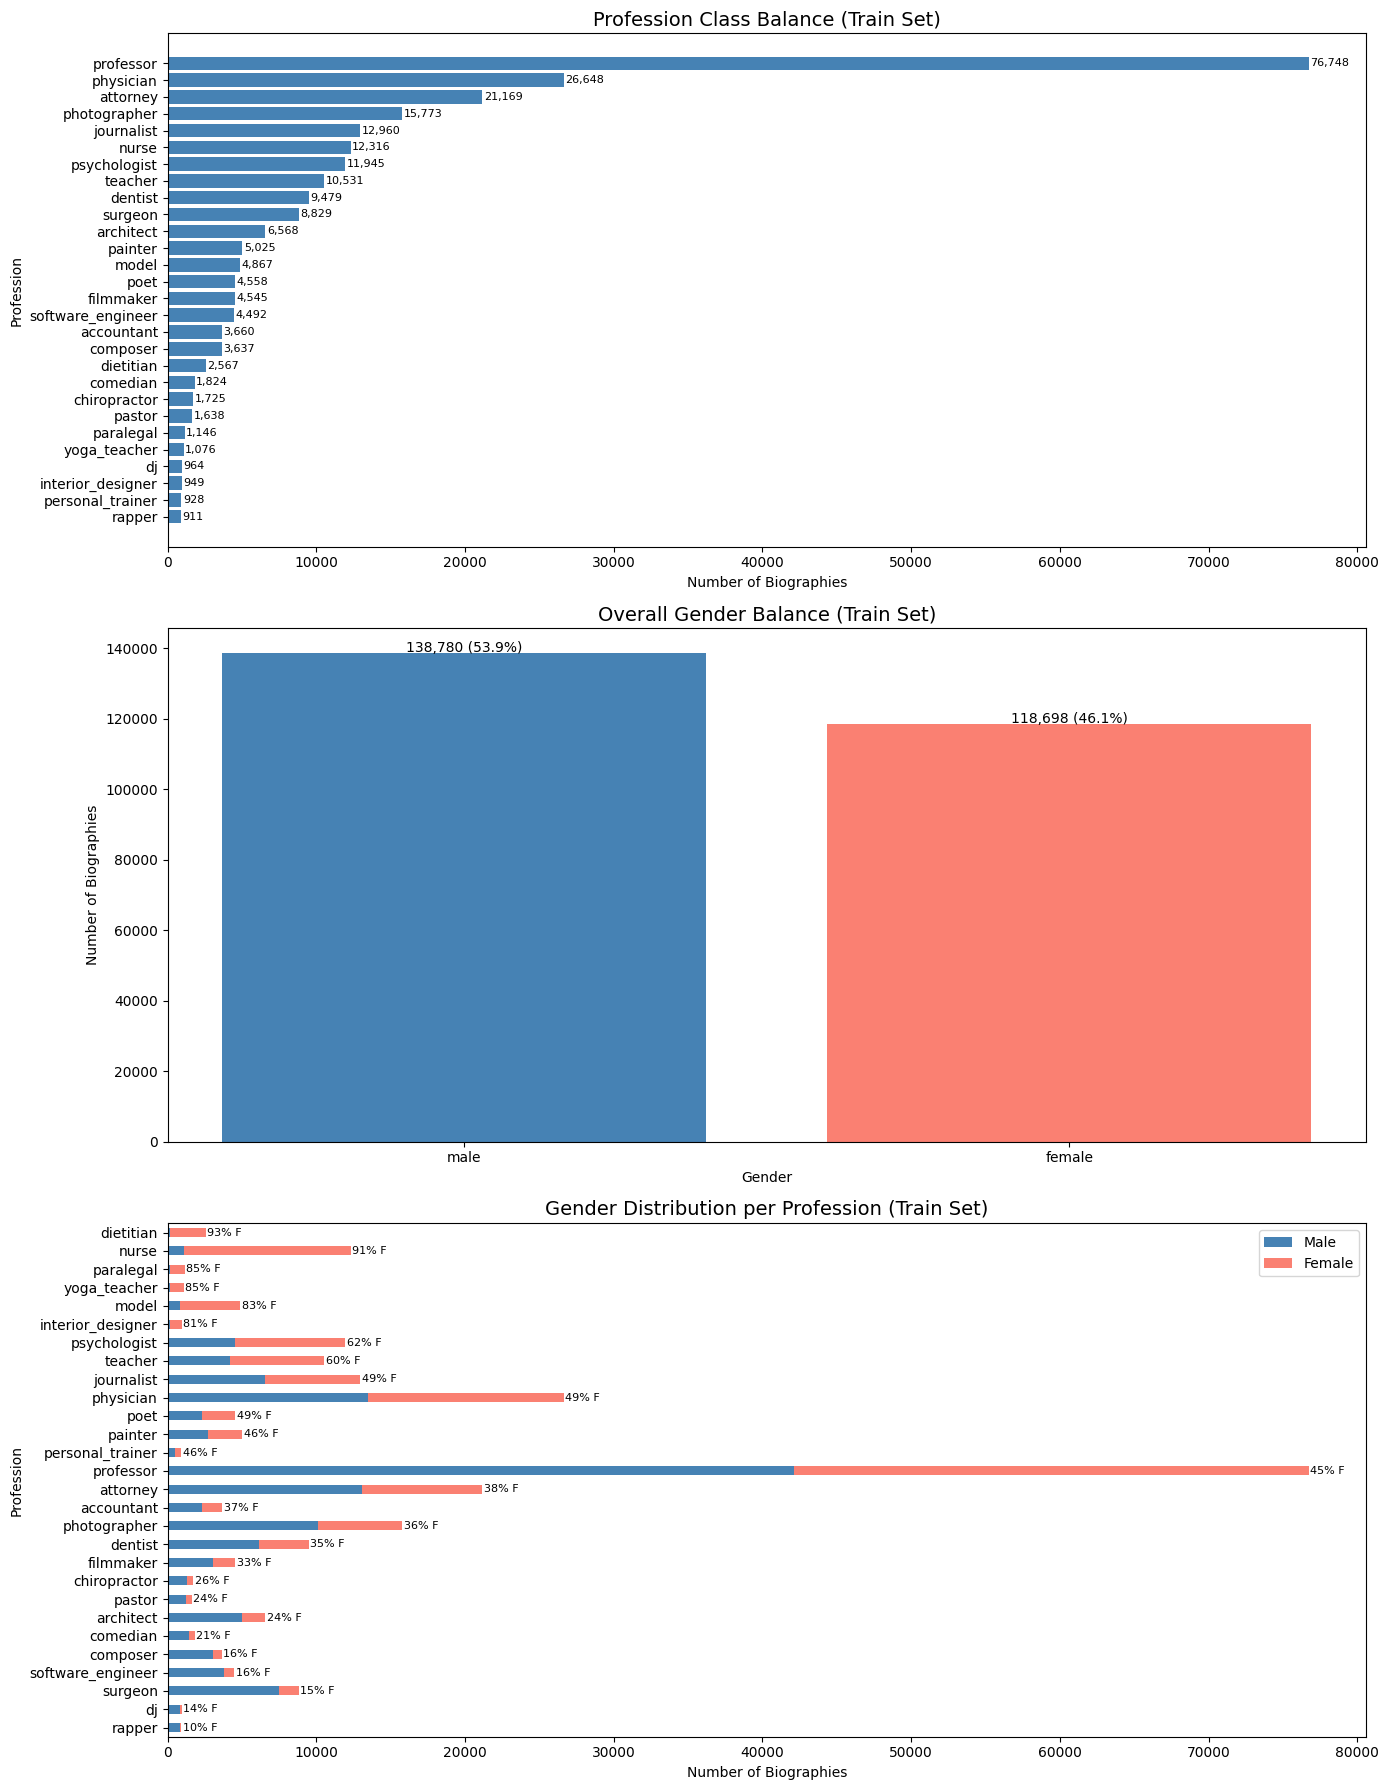


Gender x Profession counts (train set):
gender_label       female   male  total  pct_female
profession_name                                    
rapper                 88    823    911         9.7
dj                    136    828    964        14.1
surgeon              1308   7521   8829        14.8
software_engineer     709   3783   4492        15.8
composer              595   3042   3637        16.4
comedian              385   1439   1824        21.1
architect            1554   5014   6568        23.7
pastor                393   1245   1638        24.0
chiropractor          454   1271   1725        26.3
filmmaker            1497   3048   4545        32.9
dentist              3346   6133   9479        35.3
photographer         5632  10141  15773        35.7
accountant           1343   2317   3660        36.7
attorney             8105  13064  21169        38.3
professor           34618  42130  76748        45.1
personal_trainer      423    505    928        45.6
painter              22

In [ ]:
# ============================================================
# SECTION 4: EXPLORATORY DATA ANALYSIS
# ============================================================

fig, axes = plt.subplots(3, 1, figsize=(14, 18))

# ============================================================
# 4.1 Profession class balance
# Count how many biographies exist per profession in train set
# ============================================================

prof_counts = (
    train_df["profession_name"]
    .value_counts()
    .sort_values(ascending=True)
)

axes[0].barh(prof_counts.index, prof_counts.values, color="steelblue")
axes[0].set_title("Profession Class Balance (Train Set)", fontsize=14)
axes[0].set_xlabel("Number of Biographies")
axes[0].set_ylabel("Profession")
for i, v in enumerate(prof_counts.values):
    axes[0].text(v + 100, i, f"{v:,}", va="center", fontsize=8)

# ============================================================
# 4.2 Overall gender balance
# Check if male/female are roughly balanced across the full dataset
# ============================================================

gender_counts = train_df["gender_label"].value_counts()

axes[1].bar(gender_counts.index, gender_counts.values, color=["steelblue", "salmon"])
axes[1].set_title("Overall Gender Balance (Train Set)", fontsize=14)
axes[1].set_xlabel("Gender")
axes[1].set_ylabel("Number of Biographies")
for i, (label, v) in enumerate(gender_counts.items()):
    pct = v / gender_counts.sum() * 100
    axes[1].text(i, v + 200, f"{v:,} ({pct:.1f}%)", ha="center", fontsize=10)

# ============================================================
# 4.3 Gender distribution per profession
# This is the key EDA plot — shows which professions are
# male-dominated vs female-dominated, which directly predicts
# where we expect to see the largest TPR gender gaps
# ============================================================

gender_by_prof = (
    train_df.groupby(["profession_name", "gender_label"])
    .size()
    .unstack(fill_value=0)
)

# Compute female percentage and sort by it for readability
gender_by_prof["pct_female"] = (
    gender_by_prof["female"] /
    (gender_by_prof["female"] + gender_by_prof["male"]) * 100
)
gender_by_prof = gender_by_prof.sort_values("pct_female")

gender_by_prof[["male", "female"]].plot(
    kind="barh",
    stacked=True,
    ax=axes[2],
    color=["steelblue", "salmon"]
)
axes[2].set_title("Gender Distribution per Profession (Train Set)", fontsize=14)
axes[2].set_xlabel("Number of Biographies")
axes[2].set_ylabel("Profession")
axes[2].legend(["Male", "Female"])

# Add female % annotations
for i, (prof, row) in enumerate(gender_by_prof.iterrows()):
    axes[2].text(
        gender_by_prof[["male","female"]].iloc[i].sum() + 100,
        i,
        f"{row['pct_female']:.0f}% F",
        va="center",
        fontsize=8
    )

plt.tight_layout()
plt.savefig(os.path.join(CONFIG["output_dir"], "eda_plots.png"), dpi=150)
plt.show()

# ============================================================
# 4.4 Summary table: group x label counts
# Numeric version of the plot above for exact counts
# ============================================================

print("\nGender x Profession counts (train set):")
summary = (
    train_df.groupby(["profession_name", "gender_label"])
    .size()
    .unstack(fill_value=0)
    .assign(total=lambda x: x["female"] + x["male"])
    .assign(pct_female=lambda x: (x["female"] / x["total"] * 100).round(1))
    .sort_values("pct_female")
)
print(summary.to_string())

## Exploratory Data Analysis (EDA)


- Profession Class Balance

The profession class balance chart shows a heavily skewed distribution across the 28 occupations. Professor dominates with 76,748 training examples, more than double the second most frequent class, physician at 26,648. The bottom of the distribution includes rapper at 911, personal trainer at 928, and interior designer at 949. This roughly 84x difference between the most and least frequent class is worth noting because per-profession TPR estimates for rare classes will be statistically less reliable during fairness evaluation.

- Overall Gender Balance

The overall gender balance chart shows that male biographies make up 53.9% of the training set at 138,780 examples, compared to 46.1% female at 118,698 examples. The imbalance is moderate rather than severe, but the roughly 20,000 example gap means the model consistently sees more male examples during training across all professions, which could introduce a mild baseline disadvantage for female subjects independent of any occupation-specific effects.

- Gender Distribution per Profession

The stacked bar chart reveals the most consequential pattern in the dataset. Professions cluster strongly toward one gender or the other, with very few near true parity. The most male-dominated professions are rapper at 9.7% female, dj at 14.1% female, surgeon at 14.8% female, and software engineer at 15.8% female. The most female-dominated professions are dietitian at 92.9% female, nurse at 90.8% female, paralegal at 84.9% female, and yoga teacher at 84.6% female. The professions closest to parity are journalist at 49.5%, physician at 49.4%, and poet at 49.0%.

---
## Baseline Model (Transfer Learning)

### Model definition

- Pretrained encoder: DistilBERT (`distilbert-base-uncased`) with 66M parameters, pretrained on English Wikipedia and BookCorpus
- Classifier head: Linear layer mapping from 768-dimensional [CLS] token representation to 28 profession classes
- Loss: Cross-Entropy Loss

### Training setup

- Optimizer: AdamW with weight decay. AdamW is a good optimizer with many BERT models.
- Learning rate: 2e-4
    - Originally 2e-5, however this had hardware limitations where training per model would take hours and lead to a system crash
- Epochs: 3, low enough for hardware constraints.
- Batch size: 32, moderate for hardware constraints while relatively small for the large dataset.
- Early stopping / best checkpoint metric: Validation accuracy — save checkpoint whenever validation accuracy improves


In [ ]:
# Create baseline transfer learning model

model = AutoModelForSequenceClassification.from_pretrained(
    CONFIG["model_name"],
    num_labels=CONFIG["num_labels"]
)

model.to(DEVICE)
print(f"Model loaded: {CONFIG['model_name']}")
print(f"Number of labels: {CONFIG['num_labels']}")
print(f"Model moved to device: {DEVICE}")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded: distilbert-base-uncased
Number of labels: 28
Model moved to device: cuda


In [ ]:
# Training Setup
from torch.optim import AdamW
from torch.utils.data import DataLoader

train_loader = DataLoader(train_data, batch_size=CONFIG["batch_size"], shuffle=True)
val_loader = DataLoader(dev_data, batch_size=CONFIG["batch_size"])

optimizer = AdamW(model.parameters(), lr=CONFIG["learning_rate"], weight_decay=CONFIG["weight_decay"])

# Baseline 1

## Uses scrubbed bios for training

Used Claude Sonnet 4.5

LLM was asked to create a training model tracking training and validation loss and accuracy. After each epoch, the training model should save a checkpoint to ensure the best trained model is used. The model should then validate the model with the best accuracy and load it for subsequent evaluations. It should finally create a graph displaying the accuracy and loss of each epoch so that the user can create a better analysis.


Starting baseline model training...
Training on 257478 examples
Validating on 39642 examples
Device: cuda


Epoch 1/3 [Train]:   0%|          | 0/8047 [00:00<?, ?it/s]

Epoch 1/3 [Val]  :   0%|          | 0/1239 [00:00<?, ?it/s]


Epoch 1/3 Summary (Time: 1288.5s)
Train Loss: 0.7298  |  Train Acc: 0.7898
Val Loss:   0.6791  |  Val Acc:   0.8028
✓ New best model saved! (Val Acc: 0.8028)



Epoch 2/3 [Train]:   0%|          | 0/8047 [00:00<?, ?it/s]

Epoch 2/3 [Val]  :   0%|          | 0/1239 [00:00<?, ?it/s]


Epoch 2/3 Summary (Time: 1284.5s)
Train Loss: 1.9965  |  Train Acc: 0.4657
Val Loss:   2.6369  |  Val Acc:   0.2979



Epoch 3/3 [Train]:   0%|          | 0/8047 [00:00<?, ?it/s]

Epoch 3/3 [Val]  :   0%|          | 0/1239 [00:00<?, ?it/s]


Epoch 3/3 Summary (Time: 1280.7s)
Train Loss: 2.6410  |  Train Acc: 0.2981
Val Loss:   2.6390  |  Val Acc:   0.2979


TRAINING COMPLETE
Best validation accuracy: 0.8028 (Epoch 1)
Best model saved to: ./checkpoints/baseline_best.pt


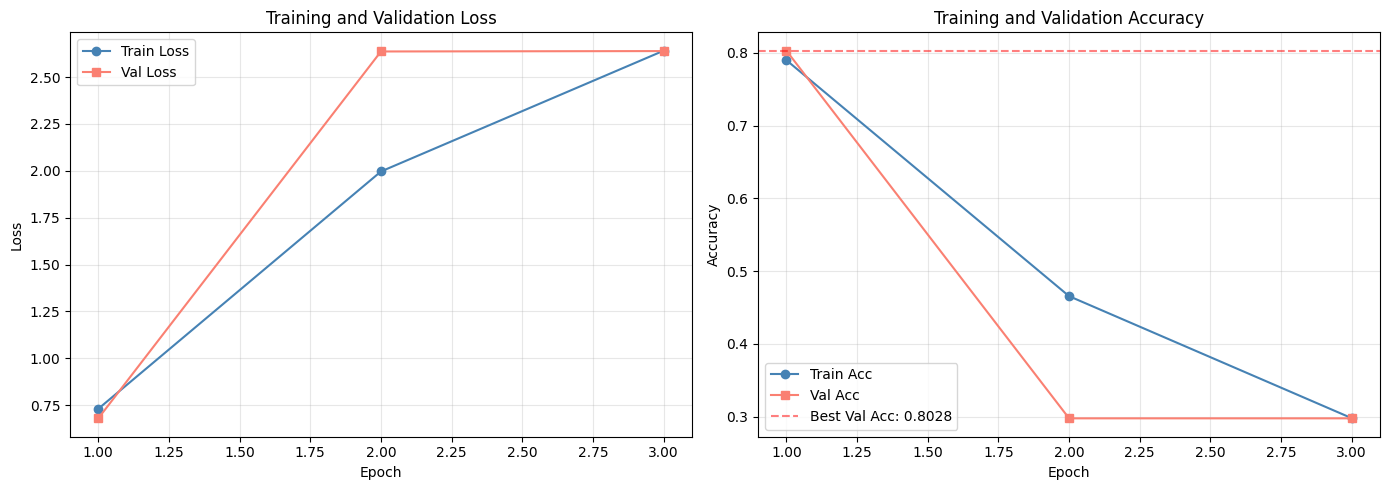


Training curves saved to: ./outputs/training_curves.png

Best model loaded from checkpoint (Epoch 1)


In [ ]:
# ============================================================
# SECTION 6: BASELINE MODEL TRAINING
# ============================================================
from tqdm.auto import tqdm
import time

print("Starting baseline model training...")
print(f"Training on {len(train_data)} examples")
print(f"Validating on {len(dev_data)} examples")
print(f"Device: {DEVICE}")

# Training hyperparameters from CONFIG
NUM_EPOCHS = CONFIG["epochs"]
BATCH_SIZE = CONFIG["batch_size"]
LEARNING_RATE = CONFIG["learning_rate"]

# Tracking metrics
train_losses = []
val_losses = []
train_accs = []
val_accs = []

best_val_acc = 0.0
best_epoch = 0

# ============================================================
# Training loop
# ============================================================
for epoch in range(NUM_EPOCHS):
    epoch_start_time = time.time()

    # ============================================================
    # Training phase
    # ============================================================
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    train_pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Train]")
    for batch in train_pbar:
        # Move batch to device
        input_ids = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels = batch["profession"].to(DEVICE)

        # Forward pass
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        logits = outputs.logits

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Track metrics
        train_loss += loss.item()
        preds = torch.argmax(logits, dim=1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

        # Update progress bar
        train_pbar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'acc': f'{train_correct/train_total:.4f}'
        })

    # Compute epoch training metrics
    avg_train_loss = train_loss / len(train_loader)
    train_acc = train_correct / train_total
    train_losses.append(avg_train_loss)
    train_accs.append(train_acc)

    # ============================================================
    # Validation phase
    # ============================================================
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    val_pbar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Val]  ")
    with torch.no_grad():
        for batch in val_pbar:
            # Move batch to device
            input_ids = batch["input_ids"].to(DEVICE)
            attention_mask = batch["attention_mask"].to(DEVICE)
            labels = batch["profession"].to(DEVICE)

            # Forward pass
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            loss = outputs.loss
            logits = outputs.logits

            # Track metrics
            val_loss += loss.item()
            preds = torch.argmax(logits, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

            # Update progress bar
            val_pbar.set_postfix({
                'loss': f'{loss.item():.4f}',
                'acc': f'{val_correct/val_total:.4f}'
            })

    # Compute epoch validation metrics
    avg_val_loss = val_loss / len(val_loader)
    val_acc = val_correct / val_total
    val_losses.append(avg_val_loss)
    val_accs.append(val_acc)

    epoch_time = time.time() - epoch_start_time

    # Print epoch summary
    print(f"\n{'='*70}")
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} Summary (Time: {epoch_time:.1f}s)")
    print(f"{'='*70}")
    print(f"Train Loss: {avg_train_loss:.4f}  |  Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {avg_val_loss:.4f}  |  Val Acc:   {val_acc:.4f}")

    # ============================================================
    # Save best model checkpoint
    # ============================================================
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch + 1

        checkpoint_path = os.path.join(CONFIG["checkpoint_dir"], "baseline_best.pt")
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc,
            'val_loss': avg_val_loss,
            'train_acc': train_acc,
            'train_loss': avg_train_loss,
        }, checkpoint_path)

        print(f"✓ New best model saved! (Val Acc: {val_acc:.4f})")

    print(f"{'='*70}\n")

# ============================================================
# Training complete
# ============================================================
print("\n" + "="*70)
print("TRAINING COMPLETE")
print("="*70)
print(f"Best validation accuracy: {best_val_acc:.4f} (Epoch {best_epoch})")
print(f"Best model saved to: {os.path.join(CONFIG['checkpoint_dir'], 'baseline_best.pt')}")

# ============================================================
# Plot training curves
# ============================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
ax1.plot(range(1, NUM_EPOCHS+1), train_losses, marker='o', label='Train Loss', color='steelblue')
ax1.plot(range(1, NUM_EPOCHS+1), val_losses, marker='s', label='Val Loss', color='salmon')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training and Validation Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy curves
ax2.plot(range(1, NUM_EPOCHS+1), train_accs, marker='o', label='Train Acc', color='steelblue')
ax2.plot(range(1, NUM_EPOCHS+1), val_accs, marker='s', label='Val Acc', color='salmon')
ax2.axhline(y=best_val_acc, color='red', linestyle='--', alpha=0.5, label=f'Best Val Acc: {best_val_acc:.4f}')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Training and Validation Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(CONFIG["output_dir"], "training_curves.png"), dpi=150)
plt.show()

print(f"\nTraining curves saved to: {os.path.join(CONFIG['output_dir'], 'training_curves.png')}")

# ============================================================
# Load best model for subsequent evaluation
# ============================================================
checkpoint_path = os.path.join(CONFIG["checkpoint_dir"], "baseline_best.pt")
checkpoint = torch.load(checkpoint_path)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"\nBest model loaded from checkpoint (Epoch {checkpoint['epoch']})")

Epoch 1 had the greatest results, so it was used as the best checkpoint. The steep drop off of epoch 2 and 3 could most likely be attributed to the learning rate being too high. In epoch 3, the accuracy hovering ~29.8% leads us to believe the model possibly started predicting all of the professions to be of one profession. This is something we feared with the accuracy metric, but did not expect to see the third epoch to match it so precisely. We can also see that the loss more than tripled between the training and validation loss. Clearly, having a high learning rate made later epochs suffer.

# Baseline 2

## Uses full bios without scrubbing names and gendered language

Used Claude Sonnet 4.5

LLM was asked to copy earlier code while making naming schema unique to evaluate later. It should prepare the full data for the unscrubbed baseline, as the data was already scrubbed by the time it came to training.


In [ ]:
# ============================================================
# SECTION 6.2: PREPARE FULL TEXT DATA FOR UNSCRUBBED BASELINE
# ============================================================

print("Preparing data for unscrubbed baseline")
print("This uses the complete original text including names and pronouns")

# The hard_text field actually contains names - use it as-is without any scrubbing
def tokenize_with_names(batch):
    """
    Tokenize hard_text directly - includes names and all gendered language.
    """
    return tokenizer(
        batch["hard_text"],
        max_length   = CONFIG["max_length"],
        truncation   = True,
        padding      = "max_length",
        return_tensors = None,
    )

# Create new dataset objects for full text training
train_data_with_names = load_dataset("LabHC/bias_in_bios", split='train')
dev_data_with_names   = load_dataset("LabHC/bias_in_bios", split='dev')
test_data_with_names  = load_dataset("LabHC/bias_in_bios", split='test')

# Tokenize with full text (names + pronouns)
train_data_with_names = train_data_with_names.map(tokenize_with_names, batched=True, batch_size=256)
dev_data_with_names   = dev_data_with_names.map(tokenize_with_names,   batched=True, batch_size=256)
test_data_with_names  = test_data_with_names.map(tokenize_with_names,  batched=True, batch_size=256)

# Set format for PyTorch
train_data_with_names.set_format(type="torch", columns=["input_ids", "attention_mask", "profession"])
dev_data_with_names.set_format(  type="torch", columns=["input_ids", "attention_mask", "profession"])
test_data_with_names.set_format( type="torch", columns=["input_ids", "attention_mask", "profession"])

Preparing data for unscrubbed baseline
This uses the complete original text including names and pronouns


Map:   0%|          | 0/257478 [00:00<?, ? examples/s]

Map:   0%|          | 0/39642 [00:00<?, ? examples/s]

Map:   0%|          | 0/99069 [00:00<?, ? examples/s]

In [ ]:
# ============================================================
# SECTION 6.3: TRAIN UNSCRUBBED BASELINE (BASELINE 2)
# ============================================================
import time
from tqdm.auto import tqdm

print("Training Baseline 2 model on full text")
print("This model has access to names AND gendered pronouns")

# Create new model instance
model_with_names = AutoModelForSequenceClassification.from_pretrained(
    CONFIG["model_name"],
    num_labels=CONFIG["num_labels"]
)
model_with_names.to(DEVICE)

# Create data loaders
train_loader_with_names = DataLoader(train_data_with_names, batch_size=CONFIG["batch_size"], shuffle=True)
val_loader_with_names   = DataLoader(dev_data_with_names,   batch_size=CONFIG["batch_size"])

# Create optimizer
optimizer_with_names = AdamW(
    model_with_names.parameters(),
    lr=CONFIG["learning_rate"],
    weight_decay=CONFIG["weight_decay"]
)

# Tracking metrics
train_losses_with_names = []
val_losses_with_names = []
train_accs_with_names = []
val_accs_with_names = []

best_val_acc_with_names = 0.0
best_epoch_with_names = 0

# ============================================================
# Training loop for baseline 2
# ============================================================
for epoch in range(CONFIG["epochs"]):
    epoch_start_time = time.time()

    # Training phase
    model_with_names.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    train_pbar = tqdm(train_loader_with_names, desc=f"Epoch {epoch+1}/{CONFIG['epochs']} [Train]")
    for batch in train_pbar:
        input_ids = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels = batch["profession"].to(DEVICE)

        outputs = model_with_names(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        logits = outputs.logits

        optimizer_with_names.zero_grad()
        loss.backward()
        optimizer_with_names.step()

        train_loss += loss.item()
        preds = torch.argmax(logits, dim=1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

        train_pbar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'acc': f'{train_correct/train_total:.4f}'
        })

    avg_train_loss = train_loss / len(train_loader_with_names)
    train_acc = train_correct / train_total
    train_losses_with_names.append(avg_train_loss)
    train_accs_with_names.append(train_acc)

    # Validation phase
    model_with_names.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    val_pbar = tqdm(val_loader_with_names, desc=f"Epoch {epoch+1}/{CONFIG['epochs']} [Val]")
    with torch.no_grad():
        for batch in val_pbar:
            input_ids = batch["input_ids"].to(DEVICE)
            attention_mask = batch["attention_mask"].to(DEVICE)
            labels = batch["profession"].to(DEVICE)

            outputs = model_with_names(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            loss = outputs.loss
            logits = outputs.logits

            val_loss += loss.item()
            preds = torch.argmax(logits, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

            val_pbar.set_postfix({
                'loss': f'{loss.item():.4f}',
                'acc': f'{val_correct/val_total:.4f}'
            })

    avg_val_loss = val_loss / len(val_loader_with_names)
    val_acc = val_correct / val_total
    val_losses_with_names.append(avg_val_loss)
    val_accs_with_names.append(val_acc)

    epoch_time = time.time() - epoch_start_time

    print(f"\n{'='*70}")
    print(f"Epoch {epoch+1}/{CONFIG['epochs']} Summary - BASELINE 2")
    print(f"{'='*70}")
    print(f"Train Loss: {avg_train_loss:.4f}  |  Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {avg_val_loss:.4f}  |  Val Acc:   {val_acc:.4f}")

    # Save best model
    if val_acc > best_val_acc_with_names:
        best_val_acc_with_names = val_acc
        best_epoch_with_names = epoch + 1

        checkpoint_path = os.path.join(CONFIG["checkpoint_dir"], "baseline_2_best.pt")
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model_with_names.state_dict(),
            'optimizer_state_dict': optimizer_with_names.state_dict(),
            'val_acc': val_acc,
            'val_loss': avg_val_loss,
            'train_acc': train_acc,
            'train_loss': avg_train_loss,
        }, checkpoint_path)

        print(f"✓ New best model saved! (Val Acc: {val_acc:.4f})")

    print(f"{'='*70}\n")

print("\n" + "="*70)
print("BASELINE 2 TRAINING COMPLETE")
print("="*70)
print(f"Best validation accuracy: {best_val_acc_with_names:.4f} (Epoch {best_epoch_with_names})")

# Load best model
checkpoint_path = os.path.join(CONFIG["checkpoint_dir"], "baseline_2_best.pt")
checkpoint = torch.load(checkpoint_path)
model_with_names.load_state_dict(checkpoint['model_state_dict'])
print(f"Best model loaded from checkpoint (Epoch {checkpoint['epoch']})")

Training Baseline 2 model on full text
This model has access to names AND gendered pronouns


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1/3 [Train]:   0%|          | 0/8047 [00:00<?, ?it/s]

Epoch 1/3 [Val]:   0%|          | 0/1239 [00:00<?, ?it/s]

...

Epoch 2/3 [Val]:   0%|          | 0/1239 [00:00<?, ?it/s]


Epoch 2/3 Summary - BASELINE 2
Train Loss: 1.0085  |  Train Acc: 0.7197
Val Loss:   2.6422  |  Val Acc:   0.2979



Epoch 3/3 [Train]:   0%|          | 0/8047 [00:00<?, ?it/s]

Epoch 3/3 [Val]:   0%|          | 0/1239 [00:00<?, ?it/s]


Epoch 3/3 Summary - BASELINE 2
Train Loss: 2.6387  |  Train Acc: 0.2981
Val Loss:   2.6417  |  Val Acc:   0.2979


BASELINE 2 TRAINING COMPLETE
Best validation accuracy: 0.8034 (Epoch 1)
Best model loaded from checkpoint (Epoch 1)


Similarly to the scrubbed text model, the regular (unscrubbed) model saw equal issues. All of the success was seen in epoch 1 and drastically fell off in epoch 2 and 3. If we were to retrain these models, using a lower training rate would be in our best interest to get higher accuracy and lower loss.

---

## Baseline Evaluation (Overall Performance)

### Metrics

We evaluate the baseline DistilBERT model on the test set using the following metrics:

- **Overall Accuracy**: The fraction of test examples where the predicted profession matches the true profession. This alone could be misleading with class imbalance. For example, a model predicting every profession to be "professor" would achieve ~29% accuracy since it makes up 29.8% of the total dataset.

- **Macro-averaged Precision/Recall/F1**: The unweighted average across all 28 professions. This treats each class equally regardless of size, which is very helpful with ensuring that categories with small sample sizes receive an equal weight to classes with more entries.

- **Weighted-averaged Precision/Recall/F1**: This metric accounts for class imbalance, and reflects the performance of the model with more frequent professions having a higher weight. With the macro-averaged metric, these two show the gap whether the model performs worse on rarer professions. For example, if the weighted scores are much higher than macro scores, the model is overfitting to the popular professions.
- **Per-class Classification Report**:
Precision - Measures false positive control for each profession
Recall - Measures false negative control for each profession
F1 - the mean of precision and recall, to find the balance of both
Support - the number of entries in the test set for this profession

- **Confusion Matrix**: We visualize the confusion matrix to see the entries that are off the diagonal, showing how the model confused professions. This helps us connect professions that are commonly confused to see if there is a logical pattern as to why this is the case. For example, professions that share the same field, like professor and teacher, may be confused since they are very similar in nature.

- **Accuracy by Profession**: The per-occupation performance breakdown to identify which professions are easiest/hardest to classify. This is important for identifying whether accuracy correlations with the sample size for a profession or gender.

These metrics establish the baseline performance level before fairness evaluation. The per-class and per-profession breakdowns are particularly important because they help identify whether accuracy correlates with class size or gender composition.


In [ ]:
# Used ChatGPT to write the following code, asking it to provide helper functions to evaluate each of the models, and explicitly mentioned to include each of the performance metrics noted above, plus any metrics it deemed beneficial for evaluation.

# ============================================================
# EVALUATION HELPERS: Overall + Gender-Disaggregated + Per-Profession-by-Gender
# ============================================================

import os
import numpy as np
import pandas as pd
import torch
from tqdm.auto import tqdm
from torch.utils.data import DataLoader
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

def ensure_gender_label(df):
    if "gender_label" not in df.columns:
        if "gender" in df.columns:
            df["gender_label"] = df["gender"].map({0: "male", 1: "female"})
        else:
            raise ValueError("Need df['gender'] or df['gender_label'] for gender-disaggregated evaluation.")
    return df

def evaluate_model_on_loader(model, loader, device):
    """Returns (preds, labels) arrays for a given model and dataloader."""
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in tqdm(loader, desc="Inference"):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["profession"].to(device)

            logits = model(input_ids=input_ids, attention_mask=attention_mask).logits
            preds = torch.argmax(logits, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return np.array(all_preds), np.array(all_labels)

def compute_overall_metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "precision_weighted": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "recall_weighted": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    }

def compute_metrics_by_gender(df, pred_col):
    """
    Computes overall metrics separately for male/female.
    Uses df['profession'] as y_true and df[pred_col] as y_pred.
    """
    rows = []
    for g in ["male", "female"]:
        sub = df[df["gender_label"] == g]
        if len(sub) == 0:
            continue
        y_true = sub["profession"].to_numpy()
        y_pred = sub[pred_col].to_numpy()
        m = compute_overall_metrics(y_true, y_pred)
        m.update({"gender": g, "n": len(sub)})
        rows.append(m)
    out = pd.DataFrame(rows).set_index("gender")
    return out

def tpr_by_profession_and_gender(df, pred_col):
    """
    Bias-in-Bios style: for each profession y, compute TPR (recall) by gender,
    then compute gap: TPR_male - TPR_female.
    Returns a dataframe with TPRs, gaps, and subgroup sizes.
    """
    rows = []
    for y in range(len(PROFESSION_LABELS)):
        for g in ["male", "female"]:
            sub = df[(df["profession"] == y) & (df["gender_label"] == g)]
            denom = len(sub)
            tpr = np.nan if denom == 0 else np.mean(sub[pred_col].to_numpy() == y)
            rows.append({
                "profession_id": y,
                "profession_name": PROFESSION_LABELS[y],
                "gender": g,
                "tpr": tpr,
                "n": denom
            })

    tpr_df = pd.DataFrame(rows)
    pivot_tpr = tpr_df.pivot(index=["profession_id", "profession_name"], columns="gender", values="tpr")
    pivot_n   = tpr_df.pivot(index=["profession_id", "profession_name"], columns="gender", values="n")

    out = pivot_tpr.copy()
    out["n_male"] = pivot_n.get("male")
    out["n_female"] = pivot_n.get("female")
    out["tpr_gap_male_minus_female"] = out["male"] - out["female"]
    out["abs_gap"] = out["tpr_gap_male_minus_female"].abs()

    # Aggregate summaries (RMS and max abs gap)
    gaps = out["tpr_gap_male_minus_female"].to_numpy()
    rms_gap = np.sqrt(np.nanmean(gaps**2))
    max_abs_gap = np.nanmax(np.abs(gaps))
    return out.reset_index(), {"rms_tpr_gap": rms_gap, "max_abs_tpr_gap": max_abs_gap}

def print_and_save_confusion_matrix(y_true, y_pred, df, title, out_path):
    """
    Confusion matrix for top-10 most frequent TRUE professions for readability,
    only counting examples where both true and pred are within top-10.
    """
    top_10_profs = df["profession_name"].value_counts().head(10).index.tolist()
    top_10_indices = [PROFESSION_LABELS.index(p) for p in top_10_profs]

    mask_true = np.isin(y_true, top_10_indices)
    mask_pred = np.isin(y_pred, top_10_indices)
    combined_mask = mask_true & mask_pred

    filtered_labels = y_true[combined_mask]
    filtered_preds = y_pred[combined_mask]

    label_mapping = {old: new for new, old in enumerate(top_10_indices)}
    remapped_labels = np.array([label_mapping[x] for x in filtered_labels])
    remapped_preds  = np.array([label_mapping[x] for x in filtered_preds])

    cm = confusion_matrix(remapped_labels, remapped_preds)

    import matplotlib.pyplot as plt
    import seaborn as sns
    fig, ax = plt.subplots(figsize=(12, 10))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=top_10_profs, yticklabels=top_10_profs, ax=ax
    )
    ax.set_xlabel("Predicted Profession")
    ax.set_ylabel("True Profession")
    ax.set_title(title)
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    if out_path:
        plt.savefig(out_path, dpi=150)
        print(f"Confusion matrix saved to: {out_path}")
    plt.show()

def run_full_evaluation(
    model,
    test_dataset,
    test_df,
    pred_col_name,
    model_label,
    checkpoint_path=None,
    save_cm=True
):
    """
    Full evaluation that:
      - optionally loads checkpoint into model
      - runs inference
      - prints overall + per-class report
      - saves predictions into test_df[pred_col_name]
      - prints gender-disaggregated overall metrics
      - prints profession-by-gender TPR + gap (Bias-in-Bios style)
    """
    test_df = ensure_gender_label(test_df)

    # Load checkpoint if provided
    if checkpoint_path is not None and os.path.exists(checkpoint_path):
        print(f"Loading checkpoint for {model_label}: {checkpoint_path}")
        ckpt = torch.load(checkpoint_path, map_location=DEVICE)
        model.load_state_dict(ckpt["model_state_dict"])
        print(f"✓ Loaded from epoch {ckpt.get('epoch','?')} | val_acc={ckpt.get('val_acc', np.nan):.4f}")
    elif checkpoint_path is not None:
        print(f"WARNING: checkpoint not found for {model_label}: {checkpoint_path}")

    # Inference
    test_loader = DataLoader(test_dataset, batch_size=CONFIG["batch_size"], shuffle=False)
    preds, labels = evaluate_model_on_loader(model, test_loader, DEVICE)

    # Overall metrics
    overall = compute_overall_metrics(labels, preds)
    print("\n" + "="*80)
    print(f"{model_label} — TEST SET PERFORMANCE (Overall)")
    print("="*80)
    for k, v in overall.items():
        print(f"{k:>18}: {v:.4f}")
    print("="*80)

    # Per-class report
    print("\n" + "="*80)
    print(f"{model_label} — PER-CLASS METRICS")
    print("="*80)
    print(classification_report(labels, preds, target_names=PROFESSION_LABELS, digits=4, zero_division=0))

    # Save predictions into test_df for later comparisons
    test_df[pred_col_name] = preds
    test_df[f"{pred_col_name}_correct"] = (test_df[pred_col_name].values == test_df["profession"].values)
    print(f"Saved predictions: test_df['{pred_col_name}'] and correctness: test_df['{pred_col_name}_correct']")

    # Confusion matrix (top-10)
    if save_cm:
        os.makedirs(CONFIG["output_dir"], exist_ok=True)
        cm_path = os.path.join(CONFIG["output_dir"], f"{pred_col_name}_confusion_top10.png")
        print_and_save_confusion_matrix(
            labels, preds, test_df,
            title=f"{model_label} — Confusion Matrix (Top 10 Professions)",
            out_path=cm_path
        )

    # Accuracy by profession (overall)
    print("\n" + "="*80)
    print(f"{model_label} — ACCURACY BY PROFESSION (Overall)")
    print("="*80)
    prof_acc = (
        test_df.groupby("profession_name")[f"{pred_col_name}_correct"]
        .agg(["sum", "count", "mean"])
        .rename(columns={"sum":"correct", "count":"total", "mean":"accuracy"})
        .sort_values("accuracy", ascending=False)
    )
    prof_acc["accuracy"] = prof_acc["accuracy"].round(4)
    print(prof_acc.to_string())

    # Gender-disaggregated overall metrics
    print("\n" + "="*80)
    print(f"{model_label} — OVERALL METRICS BY GENDER")
    print("="*80)
    by_gender = compute_metrics_by_gender(test_df, pred_col_name)
    from IPython.display import display

    float_cols = [c for c in by_gender.columns if c != "n"]
    display(
        by_gender.style
          .format("{:.4f}", subset=float_cols)
          .format("{:d}", subset=["n"])
    )

    # Bias-in-Bios: profession-by-gender TPR + gaps
    print("\n" + "="*80)
    print(f"{model_label} — PROFESSION-BY-GENDER TPR + GAP (Bias Metric)")
    print("="*80)
    tpr_table, agg = tpr_by_profession_and_gender(test_df, pred_col_name)

    print(f"Aggregate fairness summaries for {model_label}:")
    print(f"  RMS TPR gap:     {agg['rms_tpr_gap']:.4f}")
    print(f"  Max |TPR gap|:   {agg['max_abs_tpr_gap']:.4f}")

    # Show top-10 absolute gaps
    top_gap = tpr_table.sort_values("abs_gap", ascending=False).head(10)
    gap_view = top_gap[[
    "profession_name", "male", "female",
    "tpr_gap_male_minus_female", "abs_gap",
    "n_male", "n_female"
]].copy()

    display(
        gap_view.style
          # float columns
          .format("{:.4f}", subset=["male", "female", "tpr_gap_male_minus_female", "abs_gap"])
          # integer columns
          .format("{:d}", subset=["n_male", "n_female"])
          # leave profession_name alone (no formatter applied)
    )

    return test_df, overall, by_gender, tpr_table, agg

Loading checkpoint for Baseline (Scrubbed Text): ./checkpoints/baseline_best.pt
✓ Loaded from epoch 1 | val_acc=0.8028


Inference:   0%|          | 0/3096 [00:00<?, ?it/s]


Baseline (Scrubbed Text) — TEST SET PERFORMANCE (Overall)
          accuracy: 0.8046
   precision_macro: 0.7634
      recall_macro: 0.7247
          f1_macro: 0.7287
precision_weighted: 0.8153
   recall_weighted: 0.8046
       f1_weighted: 0.8042

Baseline (Scrubbed Text) — PER-CLASS METRICS
                   precision    recall  f1-score   support

       accountant     0.7343    0.7374    0.7358      1409
        architect     0.5957    0.7326    0.6571      2528
         attorney     0.8177    0.9140    0.8632      8143
     chiropractor     0.8668    0.5392    0.6648       664
         comedian     0.8722    0.7183    0.7878       703
         composer     0.7803    0.8415    0.8098      1401
          dentist     0.9001    0.9512    0.9249      3647
        dietitian     0.7606    0.8382    0.7975       989
               dj     0.7173    0.7366    0.7268       372
        filmmaker     0.8802    0.6383    0.7400      1750
interior_designer     0.5854    0.5055    0.5425       3

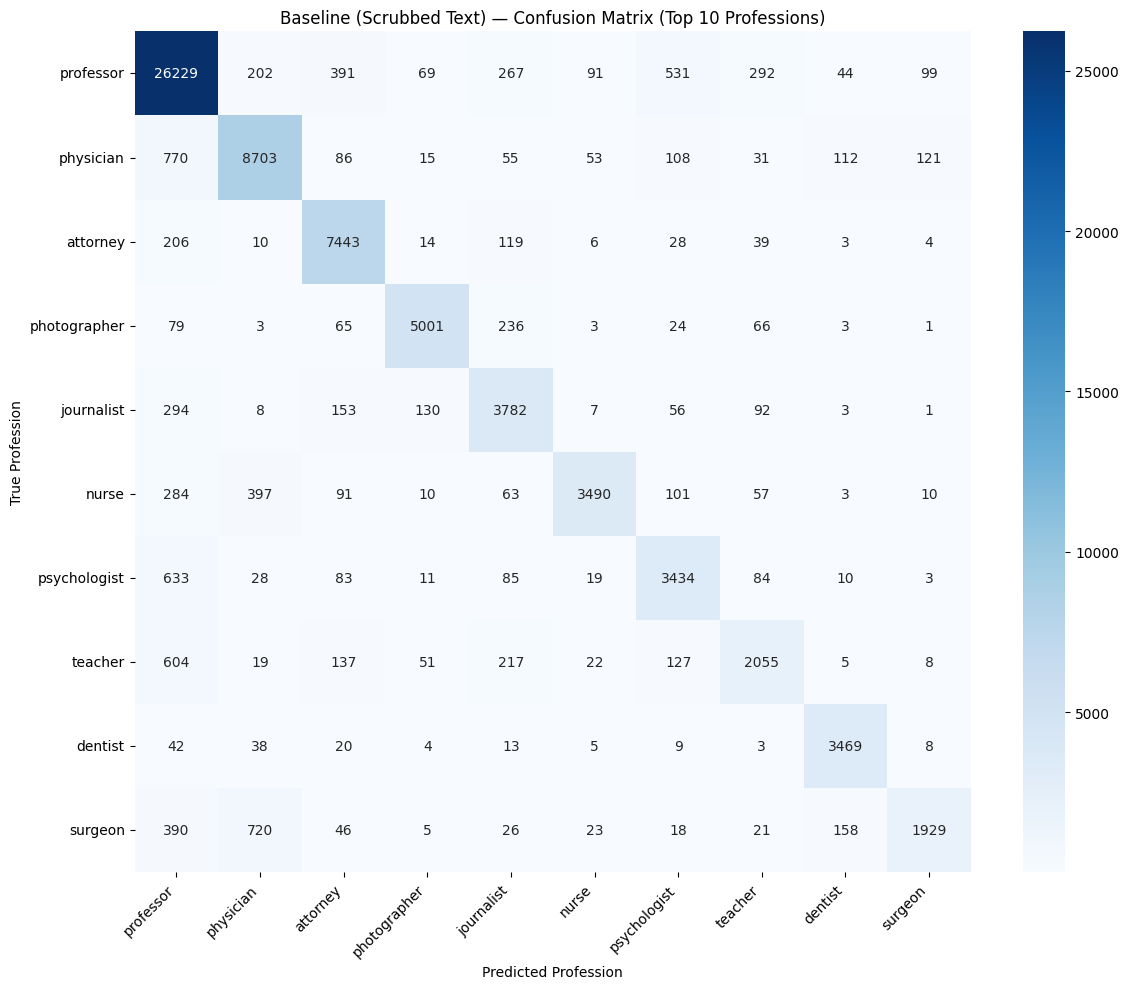


Baseline (Scrubbed Text) — ACCURACY BY PROFESSION (Overall)
                   correct  total  accuracy
profession_name                            
dentist               3469   3647    0.9512
attorney              7443   8143    0.9140
professor            26229  29520    0.8885
painter               1696   1935    0.8765
pastor                 544    632    0.8608
physician             8703  10250    0.8491
composer              1179   1401    0.8415
dietitian              829    989    0.8382
poet                  1466   1754    0.8358
photographer          5001   6068    0.8242
yoga_teacher           325    416    0.7812
journalist            3782   4986    0.7585
psychologist          3434   4596    0.7472
accountant            1039   1409    0.7374
nurse                 3490   4738    0.7366
dj                     274    372    0.7366
architect             1852   2528    0.7326
comedian               505    703    0.7183
model                 1251   1874    0.6676
rapper         

,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,n
gender,,,,,,,,
male,0.8002,0.7197,0.6954,0.6886,0.8093,0.8002,0.7987,53397
female,0.8099,0.7378,0.7147,0.7081,0.8236,0.8099,0.8111,45672



Baseline (Scrubbed Text) — PROFESSION-BY-GENDER TPR + GAP (Bias Metric)
Aggregate fairness summaries for Baseline (Scrubbed Text):
  RMS TPR gap:     0.1195
  Max |TPR gap|:   0.4675


gender,profession_name,male,female,tpr_gap_male_minus_female,abs_gap,n_male,n_female
12,model,0.2809,0.7484,-0.4675,0.4675,324,1550
7,dietitian,0.6479,0.8529,-0.2051,0.2051,71,918
15,paralegal,0.2985,0.4720,-0.1735,0.1735,67,375
25,surgeon,0.5905,0.4365,0.1540,0.1540,2894,504
8,dj,0.7555,0.6226,0.1328,0.1328,319,53
23,rapper,0.6562,0.5294,0.1267,0.1267,317,34
16,pastor,0.8875,0.7763,0.1112,0.1112,480,152
26,teacher,0.4444,0.5488,-0.1043,0.1043,1611,2440
19,physician,0.8133,0.8858,-0.0725,0.0725,5190,5060
17,personal_trainer,0.5897,0.6503,-0.0606,0.0606,195,163


In [ ]:
# ============================================================
# SECTION 7: BASELINE EVALUATION (SCRUBBED TEXT)
# ============================================================

baseline_ckpt = os.path.join(CONFIG["checkpoint_dir"], "baseline_best.pt")

test_df, baseline_overall, baseline_by_gender, baseline_tpr_table, baseline_fair_agg = run_full_evaluation(
    model=model,
    test_dataset=test_data,
    test_df=test_df,
    pred_col_name="baseline_pred",
    model_label="Baseline (Scrubbed Text)",
    checkpoint_path=baseline_ckpt,
    save_cm=True
)

This confusion matrix shows how the scrubbed-text baseline performs as it predicts professions. This matrix shows the highly accurate classification as well as the semantic confusion between logically similar fields. The diagonal values indicate that the model predicted correctly, which is particularly high for professions with distinct language patterns, like professor, physician, attorney, and photographer. This could mean that the model is able to capture domain-specific terms from the bios and use them as contextual clues for making predictions. There are several consistent misclassifications where multiple professions may have similar wording in bios like professors and surgeons, which could possibly reflect a shared academic terminology. Teachers are also commonly predicted as professors, making it clear that the model struggles to separate the two professions when there are many similarities in the bios. Overall, the matrix suggests the model performs well when professions have unique linguistic markers but struggles when multiple occupations share those same markers. This leads us to believe it is semantic similarity that drives most of the errors.


Overall Performance (Baseline 1)

Accuracy (0.8046)
- Model correctly predicts the profession ~80% of the time across ~99k biographies.
- Influenced by large classes (e.g., professor).

Macro Precision (0.7634)
- When the model predicts a profession, it is correct ~76% of the time averaged equally across professions.

Macro Recall (0.7247)
- The model correctly identifies ~72% of people in each profession on average.

Macro F1 (0.7287)
- Balanced measure of precision & recall across professions.

Weighted Precision (0.8153)
- Precision accounting for profession frequency (common jobs weigh more).

Weighted Recall (0.8046)
- Same as accuracy in multiclass settings.

Weighted F1 (0.8042)
- Overall balanced performance reflecting real-world class distribution.

Bias Metric: TPR (True Positive Rate) Gap
- Measures whether professions are identified equally across genders.
- Large gap: one gender recognized more accurately.
- RMS gap (0.1195): average disparity
- Max gap (0.4675): worst disparity


Loading checkpoint for Baseline 2 (Full Text: Names + Pronouns): ./checkpoints/baseline_2_best.pt
✓ Loaded from epoch 1 | val_acc=0.8034


Inference:   0%|          | 0/3096 [00:00<?, ?it/s]


Baseline 2 (Full Text: Names + Pronouns) — TEST SET PERFORMANCE (Overall)
          accuracy: 0.8064
   precision_macro: 0.7517
      recall_macro: 0.7240
          f1_macro: 0.7292
precision_weighted: 0.8115
   recall_weighted: 0.8064
       f1_weighted: 0.8056

Baseline 2 (Full Text: Names + Pronouns) — PER-CLASS METRICS
                   precision    recall  f1-score   support

       accountant     0.8610    0.6636    0.7495      1409
        architect     0.8347    0.4695    0.6010      2528
         attorney     0.9280    0.8101    0.8651      8143
     chiropractor     0.6682    0.6521    0.6601       664
         comedian     0.8355    0.7155    0.7709       703
         composer     0.7856    0.8394    0.8116      1401
          dentist     0.9306    0.9081    0.9192      3647
        dietitian     0.6937    0.8564    0.7665       989
               dj     0.6651    0.7581    0.7085       372
        filmmaker     0.8177    0.7589    0.7872      1750
interior_designer     0.

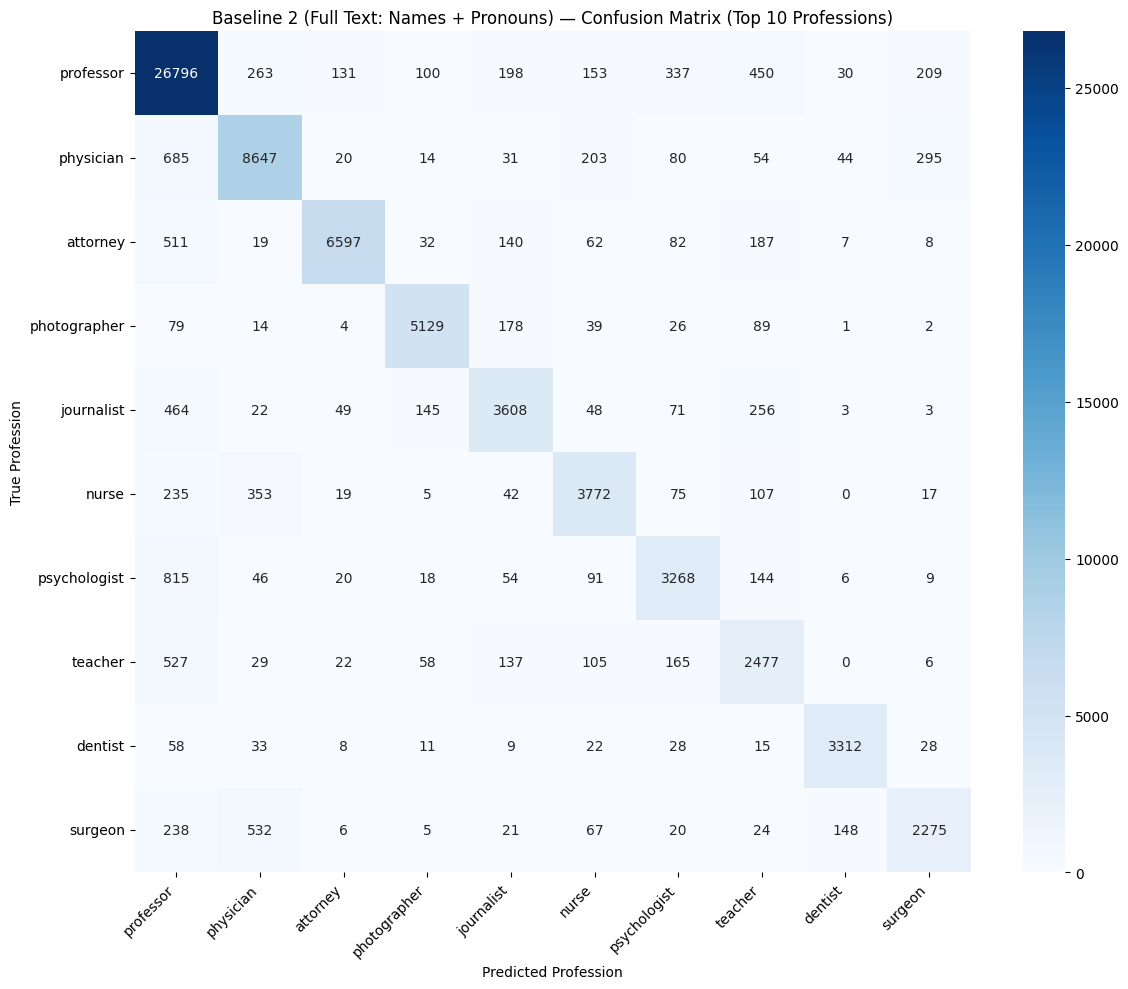


Baseline 2 (Full Text: Names + Pronouns) — ACCURACY BY PROFESSION (Overall)
                   correct  total  accuracy
profession_name                            
dentist               3312   3647    0.9081
professor            26796  29520    0.9077
painter               1679   1935    0.8677
dietitian              847    989    0.8564
photographer          5129   6068    0.8453
physician             8647  10250    0.8436
composer              1176   1401    0.8394
attorney              6597   8143    0.8101
nurse                 3772   4738    0.7961
model                 1469   1874    0.7839
filmmaker             1328   1750    0.7589
dj                     282    372    0.7581
software_engineer     1302   1728    0.7535
poet                  1311   1754    0.7474
journalist            3608   4986    0.7236
comedian               503    703    0.7155
paralegal              316    442    0.7149
psychologist          3268   4596    0.7111
surgeon               2275   3398    0.6695

,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,n
gender,,,,,,,,
male,0.8016,0.6907,0.6935,0.6802,0.8089,0.8016,0.8011,53397
female,0.8119,0.7557,0.6874,0.7055,0.8156,0.8119,0.8107,45672



Baseline 2 (Full Text: Names + Pronouns) — PROFESSION-BY-GENDER TPR + GAP (Bias Metric)
Aggregate fairness summaries for Baseline 2 (Full Text: Names + Pronouns):
  RMS TPR gap:     0.1681
  Max |TPR gap|:   0.4962


gender,profession_name,male,female,tpr_gap_male_minus_female,abs_gap,n_male,n_female
12,model,0.3735,0.8697,-0.4962,0.4962,324,1550
23,rapper,0.4984,0.0588,0.4396,0.4396,317,34
25,surgeon,0.7087,0.4444,0.2643,0.2643,2894,504
16,pastor,0.7063,0.4671,0.2391,0.2391,480,152
15,paralegal,0.5224,0.7493,-0.2269,0.2269,67,375
7,dietitian,0.6761,0.8704,-0.1943,0.1943,71,918
3,chiropractor,0.6912,0.5429,0.1483,0.1483,489,175
26,teacher,0.5258,0.6680,-0.1423,0.1423,1611,2440
10,interior_designer,0.5070,0.6475,-0.1404,0.1404,71,295
8,dj,0.7774,0.6415,0.1359,0.1359,319,53


In [ ]:
# ============================================================
# SECTION 7: BASELINE 2 EVALUATION (FULL TEXT: NAMES + PRONOUNS)
# ============================================================

baseline2_ckpt = os.path.join(CONFIG["checkpoint_dir"], "baseline_2_best.pt")

test_df, baseline2_overall, baseline2_by_gender, baseline2_tpr_table, baseline2_fair_agg = run_full_evaluation(
    model=model_with_names,
    test_dataset=test_data_with_names,
    test_df=test_df,
    pred_col_name="baseline_with_names_pred",
    model_label="Baseline 2 (Full Text: Names + Pronouns)",
    checkpoint_path=baseline2_ckpt,
    save_cm=True
)

This confusion matrix suffers from the same shortcomings as the scrubbed model’s matrix. Professions that share semantic similarities are more often misclassified than professions that are semantically different. However, for the full text model, gendered language now plays into the misclassifications. This shows that there is a bias within the pretrained model. For example, there is confusion between surgeon and physician (532) and nurse and physician (353) remains strong, but the persistence of these patterns alongside known gender biases in nursing and surgical fields suggests the model may be leveraging the gendered biases to reinforce hierarchical assumptions within medicine. When compared with the scrubbed baseline model, the full-text model shows slightly more prediction bias toward professions that are historically associated with specific genders, implying that the inclusion of names and gendered language provides a shortcut that the model exploits.



Overall Performance (Baseline 2)

Accuracy (0.8064)
- The model correctly predicts the profession ~80.6% of the time.
- Slight increase compared to scrubbed text.

Macro Precision (0.7517)
- When predicting a profession, it is correct ~75% of the time on average across professions.
- There is a slight decrease, so there are more false positives.

Macro Recall (0.7240)
- Correctly identifies ~72% of people in each profession on average.

Macro F1 (0.7292)
- Balanced precision & recall across professions.

Weighted Precision (0.8115)
- Precision weighted by class size.

Weighted Recall (0.8064)
- Come out to be equivalent to accuracy.

Weighted F1 (0.8056)
- Overall balanced performance with the class distribution.


## Train Mitigated Model (CLP)

### Training notes

- Same architecture as baseline
- Same data splits
- Only change: add CLP loss term using counterfactual pairs

### About CLP

The original paper does perform a gender swap on the test set to see how different the predictions are to measure bias in the trained model, but we contribute by incorprating that into the training and penalizing when the predictions are different:

Counterfactual logit pairing (CLP) is a bias mitigation technique our group was introduced to when looking up bias mitigation strategy options, being introduced to this [Tensorflow Blog](https://blog.tensorflow.org/2023/04/counterfactual-logit-pairing.html) and [an application on a toxicity dataset](https://arxiv.org/pdf/1809.10610). The goal is to make the model's prediction invariant to gender, by way of penalizing whenever the output changes after swapping the genders.

For each biography, we create a counterfactual version (using the gender swap discussed previously), and it trains the model to:
1. Like the previous models, still predict profession,
2. but also produce similar logits for the original and counterfactual bios.

The 2nd discourages the model to rely on the gendered indicators as a shortcut to predict profession through the pairing loss.

### Argument for CLP
CLP is a stronger mitigation technique than simply scrubbing the gender indicator because it targets the behavior we actually care about: in that the prediction should not change based on when only the gender terms change. This method seeks to penalize the bias to train better and be fair, rather than just eliminating factors that could contribute to the bias, making it more align with addressing the bias at hand. CLP keeps the full text (and doesn't throw any information away), and adds a training constraing (the pairing loss) to penalize gender-sensitve logits so that the model relies on profession evidence rather than gender evidence.

### CLP in the Code

1. First we generate the counterfactual bios: `example["hard_text_cf"] = swap_gender(example["hard_text"])`

2. Then we tokenize both the original and counterfactual bios so that each training example has both as inputs: `"input_ids", "attention_mask", "cf_input_ids", "cf_attention_mask"`

3. We define a pairing loss: `pair = pairing_loss(logits, logits_cf, kind="mse")`, using `mse` to force the logits to be close, but another option we could have tried is using KL to force the predicted distributions to be close rather than the logits.

4. The new loss function of the model uses the pairing loss: `loss = ce + lambda_clp * pair`, with `lambda_clp` being able to control the fairness and accuracy tradeoff. We use a lambda of 0.5, but further experimentation could be done to tweak lambda to improve accuracy or fairness. ce is the classification objective.

5. Two forward passes are done per batch, with one on the original text with labels to produce ce, and one on the counterfactual bios to produce the logits for the pairing penaly. Gradients flow through both so that the model is trained to align both outputs together.

In [ ]:
# Providing the code previously done for the baseline1 training and the gender_swap, I asked ChatGPT to write the code using the same model type and parameter to train a model using Counterfactual Logit Pairing as a new loss function

# ============================================================
# SECTION 8: CLP (Counterfactual Logit Pairing) — Implement / Train / Test
# ============================================================

import os
import time
import numpy as np
import torch
import torch.nn.functional as F
from tqdm.auto import tqdm
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.optim import AdamW
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# -----------------------------
# 8.0 CLP hyperparameters
# -----------------------------
CLP_CONFIG = {
    "lambda_clp": 0.5,          # strength of pairing loss (tune: 0.1, 0.5, 1.0)
    "pair_loss": "mse",
    "epochs": CONFIG["epochs"],
    "batch_size": CONFIG["batch_size"],
    "lr": CONFIG["learning_rate"],
    "weight_decay": CONFIG["weight_decay"],
    "max_length": CONFIG["max_length"],
    "checkpoint_name": "clp_best.pt",
}

CLP_CHECKPOINT_PATH = os.path.join(CONFIG["checkpoint_dir"], CLP_CONFIG["checkpoint_name"])

train_clp = load_dataset("LabHC/bias_in_bios", split="train")
dev_clp   = load_dataset("LabHC/bias_in_bios", split="dev")
test_clp  = load_dataset("LabHC/bias_in_bios", split="test")

# Add counterfactual (gender-swapped) text column
def add_counterfactual(example):
    example["hard_text_cf"] = swap_gender(example["hard_text"])
    return example

train_clp = train_clp.map(add_counterfactual, batched=False)
dev_clp   = dev_clp.map(add_counterfactual, batched=False)
test_clp  = test_clp.map(add_counterfactual, batched=False)

# -----------------------------
# 8.2 Tokenize BOTH original and counterfactual texts
# -----------------------------
tokenizer = AutoTokenizer.from_pretrained(CONFIG["model_name"])

def tokenize_clp(batch):
    enc = tokenizer(
        batch["hard_text"],
        max_length=CLP_CONFIG["max_length"],
        truncation=True,
        padding="max_length",
    )
    enc_cf = tokenizer(
        batch["hard_text_cf"],
        max_length=CLP_CONFIG["max_length"],
        truncation=True,
        padding="max_length",
    )
    return {
        "input_ids": enc["input_ids"],
        "attention_mask": enc["attention_mask"],
        "cf_input_ids": enc_cf["input_ids"],
        "cf_attention_mask": enc_cf["attention_mask"],
    }

train_clp = train_clp.map(tokenize_clp, batched=True, batch_size=256)
dev_clp   = dev_clp.map(tokenize_clp, batched=True, batch_size=256)
test_clp  = test_clp.map(tokenize_clp, batched=True, batch_size=256)

# Keep columns needed for CLP training
train_clp.set_format(type="torch", columns=["input_ids","attention_mask","cf_input_ids","cf_attention_mask","profession"])
dev_clp.set_format(type="torch", columns=["input_ids","attention_mask","cf_input_ids","cf_attention_mask","profession"])
test_clp.set_format(type="torch", columns=["input_ids","attention_mask","cf_input_ids","cf_attention_mask","profession"])

print("CLP tokenization complete.")
print("Example shapes:",
      train_clp[0]["input_ids"].shape,
      train_clp[0]["cf_input_ids"].shape)

# -----------------------------
# 8.3 Build model + loaders + optimizer
# -----------------------------
clp_model = AutoModelForSequenceClassification.from_pretrained(
    CONFIG["model_name"],
    num_labels=CONFIG["num_labels"]
).to(DEVICE)

train_loader = DataLoader(train_clp, batch_size=CLP_CONFIG["batch_size"], shuffle=True)
val_loader   = DataLoader(dev_clp,   batch_size=CLP_CONFIG["batch_size"], shuffle=False)
test_loader  = DataLoader(test_clp,  batch_size=CLP_CONFIG["batch_size"], shuffle=False)

optimizer = AdamW(clp_model.parameters(), lr=CLP_CONFIG["lr"], weight_decay=CLP_CONFIG["weight_decay"])

# -----------------------------
# 8.4 Pairing loss function
# -----------------------------
def pairing_loss(logits, logits_cf, kind="mse"):
    """
    logits, logits_cf: [B, num_labels]
    """
    if kind == "mse":
        return F.mse_loss(logits, logits_cf)
    elif kind == "kl":
        # KL( p || q ) with p=softmax(logits) and q=softmax(logits_cf)
        # Use batchmean for stable scale
        p_log = F.log_softmax(logits, dim=-1)
        q = F.softmax(logits_cf, dim=-1)
        return F.kl_div(p_log, q, reduction="batchmean")
    else:
        raise ValueError("pair_loss must be 'mse' or 'kl'")

# -----------------------------
# 8.5 Train CLP model (CE + lambda * pairing)
# -----------------------------
print("\nStarting CLP training...")
best_val_acc = 0.0
best_epoch = 0

train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(CLP_CONFIG["epochs"]):
    epoch_start = time.time()

    # ---- Train
    clp_model.train()
    total_loss = 0.0
    total_ce = 0.0
    total_pair = 0.0
    correct = 0
    seen = 0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{CLP_CONFIG['epochs']} [CLP Train]")
    for batch in pbar:
        input_ids = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        cf_input_ids = batch["cf_input_ids"].to(DEVICE)
        cf_attention_mask = batch["cf_attention_mask"].to(DEVICE)
        labels = batch["profession"].to(DEVICE)

        # Forward on original
        out = clp_model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        ce = out.loss
        logits = out.logits

        # Forward on counterfactual (NO no_grad -> symmetric CLP; gradients flow through both)
        out_cf = clp_model(input_ids=cf_input_ids, attention_mask=cf_attention_mask)
        logits_cf = out_cf.logits

        pair = pairing_loss(logits, logits_cf, kind=CLP_CONFIG["pair_loss"])

        loss = ce + CLP_CONFIG["lambda_clp"] * pair

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(clp_model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()
        total_ce += ce.item()
        total_pair += pair.item()

        preds = torch.argmax(logits, dim=1)
        correct += (preds == labels).sum().item()
        seen += labels.size(0)

        pbar.set_postfix({
            "loss": f"{loss.item():.4f}",
            "ce": f"{ce.item():.4f}",
            "pair": f"{pair.item():.4f}",
            "acc": f"{correct/seen:.4f}"
        })

    avg_train_loss = total_loss / len(train_loader)
    train_acc = correct / seen
    train_losses.append(avg_train_loss)
    train_accs.append(train_acc)

    # ---- Validate (use standard CE + accuracy on original text only)
    clp_model.eval()
    vloss = 0.0
    vcorrect = 0
    vseen = 0

    vbar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{CLP_CONFIG['epochs']} [CLP Val]  ")
    with torch.no_grad():
        for batch in vbar:
            input_ids = batch["input_ids"].to(DEVICE)
            attention_mask = batch["attention_mask"].to(DEVICE)
            labels = batch["profession"].to(DEVICE)

            out = clp_model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            loss = out.loss
            logits = out.logits

            vloss += loss.item()
            preds = torch.argmax(logits, dim=1)
            vcorrect += (preds == labels).sum().item()
            vseen += labels.size(0)

            vbar.set_postfix({"loss": f"{loss.item():.4f}", "acc": f"{vcorrect/vseen:.4f}"})

    avg_val_loss = vloss / len(val_loader)
    val_acc = vcorrect / vseen
    val_losses.append(avg_val_loss)
    val_accs.append(val_acc)

    elapsed = time.time() - epoch_start
    print("\n" + "="*70)
    print(f"Epoch {epoch+1} Summary (Time: {elapsed:.1f}s)")
    print("="*70)
    print(f"Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"  - Avg CE Loss:    {total_ce/len(train_loader):.4f}")
    print(f"  - Avg Pair Loss:  {total_pair/len(train_loader):.4f} (lambda={CLP_CONFIG['lambda_clp']}, kind={CLP_CONFIG['pair_loss']})")
    print(f"Val Loss:   {avg_val_loss:.4f} | Val Acc:   {val_acc:.4f}")

    # Save best checkpoint by val accuracy
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch + 1
        os.makedirs(CONFIG["checkpoint_dir"], exist_ok=True)

        torch.save({
            "epoch": best_epoch,
            "model_state_dict": clp_model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "val_acc": val_acc,
            "val_loss": avg_val_loss,
            "train_acc": train_acc,
            "train_loss": avg_train_loss,
            "clp_config": CLP_CONFIG,
        }, CLP_CHECKPOINT_PATH)

        print(f"✓ New best CLP model saved: {CLP_CHECKPOINT_PATH} (Val Acc: {val_acc:.4f})")
    print("="*70 + "\n")

print("="*70)
print("CLP TRAINING COMPLETE")
print("="*70)
print(f"Best validation accuracy: {best_val_acc:.4f} (Epoch {best_epoch})")
print(f"Best checkpoint: {CLP_CHECKPOINT_PATH}")


Map:   0%|          | 0/257478 [00:00<?, ? examples/s]

Map:   0%|          | 0/39642 [00:00<?, ? examples/s]

Map:   0%|          | 0/99069 [00:00<?, ? examples/s]

Map:   0%|          | 0/257478 [00:00<?, ? examples/s]

Map:   0%|          | 0/39642 [00:00<?, ? examples/s]

...

Epoch 2/3 [CLP Val]  :   0%|          | 0/1239 [00:00<?, ?it/s]


Epoch 2 Summary (Time: 2378.6s)
Train Loss: 0.5946 | Train Acc: 0.8390
  - Avg CE Loss:    0.5630
  - Avg Pair Loss:  0.0633 (lambda=0.5, kind=mse)
Val Loss:   0.6570 | Val Acc:   0.8122



Epoch 3/3 [CLP Train]:   0%|          | 0/8047 [00:00<?, ?it/s]

Epoch 3/3 [CLP Val]  :   0%|          | 0/1239 [00:00<?, ?it/s]


Epoch 3 Summary (Time: 2367.7s)
Train Loss: 0.5004 | Train Acc: 0.8659
  - Avg CE Loss:    0.4694
  - Avg Pair Loss:  0.0621 (lambda=0.5, kind=mse)
Val Loss:   0.6567 | Val Acc:   0.8181
✓ New best CLP model saved: ./checkpoints/clp_best.pt (Val Acc: 0.8181)

CLP TRAINING COMPLETE
Best validation accuracy: 0.8181 (Epoch 3)
Best checkpoint: ./checkpoints/clp_best.pt


---

## Mitigated Evaluation (Performance + Fairness)


Loaded best CLP checkpoint from epoch 3 (Val Acc=0.8181)
Loading checkpoint for CLP (Mitigation): ./checkpoints/clp_best.pt
✓ Loaded from epoch 3 | val_acc=0.8181


Inference:   0%|          | 0/3096 [00:00<?, ?it/s]


CLP (Mitigation) — TEST SET PERFORMANCE (Overall)
          accuracy: 0.8203
   precision_macro: 0.7674
      recall_macro: 0.7538
          f1_macro: 0.7537
precision_weighted: 0.8242
   recall_weighted: 0.8203
       f1_weighted: 0.8201

CLP (Mitigation) — PER-CLASS METRICS
                   precision    recall  f1-score   support

       accountant     0.8289    0.7218    0.7716      1409
        architect     0.7008    0.6586    0.6790      2528
         attorney     0.8973    0.8783    0.8877      8143
     chiropractor     0.8426    0.6370    0.7256       664
         comedian     0.6164    0.8321    0.7082       703
         composer     0.7166    0.8986    0.7973      1401
          dentist     0.8930    0.9613    0.9259      3647
        dietitian     0.8046    0.8160    0.8102       989
               dj     0.6433    0.7661    0.6994       372
        filmmaker     0.7474    0.8080    0.7765      1750
interior_designer     0.6606    0.6913    0.6756       366
       journa

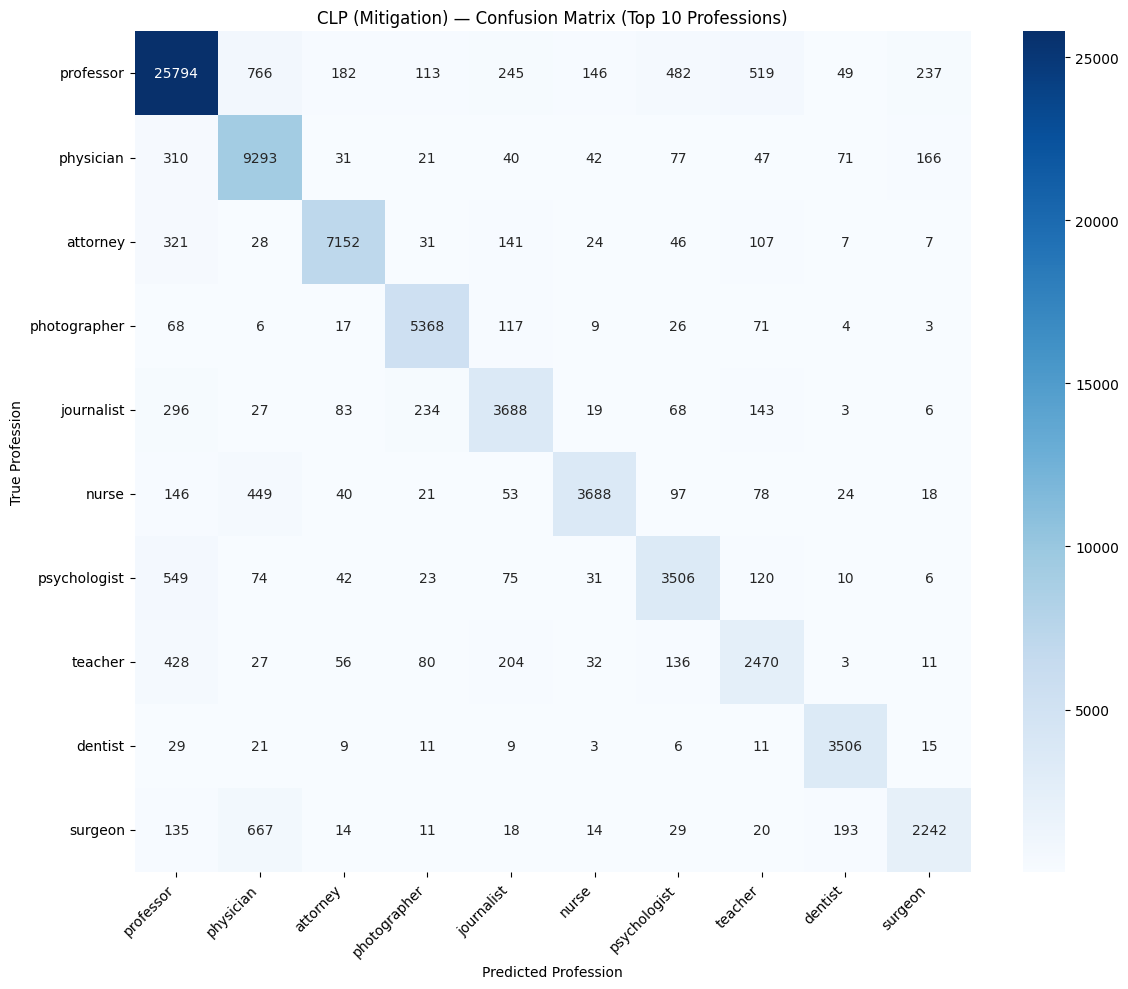


CLP (Mitigation) — ACCURACY BY PROFESSION (Overall)
                   correct  total  accuracy
profession_name                            
dentist               3506   3647    0.9613
physician             9293  10250    0.9066
composer              1259   1401    0.8986
photographer          5368   6068    0.8846
attorney              7152   8143    0.8783
professor            25794  29520    0.8738
comedian               585    703    0.8321
dietitian              807    989    0.8160
yoga_teacher           338    416    0.8125
filmmaker             1414   1750    0.8080
painter               1532   1935    0.7917
nurse                 3688   4738    0.7784
poet                  1353   1754    0.7714
dj                     285    372    0.7661
psychologist          3506   4596    0.7628
journalist            3688   4986    0.7397
pastor                 464    632    0.7342
accountant            1017   1409    0.7218
model                 1351   1874    0.7209
interior_designer      

,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,n
gender,,,,,,,,
male,0.8159,0.7196,0.7195,0.7105,0.8191,0.8159,0.8151,53397
female,0.8255,0.7398,0.7404,0.7306,0.8309,0.8255,0.8261,45672



CLP (Mitigation) — PROFESSION-BY-GENDER TPR + GAP (Bias Metric)
Aggregate fairness summaries for CLP (Mitigation):
  RMS TPR gap:     0.1353
  Max |TPR gap|:   0.4761


gender,profession_name,male,female,tpr_gap_male_minus_female,abs_gap,n_male,n_female
12,model,0.3272,0.8032,-0.4761,0.4761,324,1550
15,paralegal,0.3582,0.6133,-0.2551,0.2551,67,375
7,dietitian,0.5915,0.8333,-0.2418,0.2418,71,918
23,rapper,0.5331,0.2941,0.2390,0.2390,317,34
8,dj,0.7931,0.6038,0.1893,0.1893,319,53
26,teacher,0.5289,0.6631,-0.1343,0.1343,1611,2440
25,surgeon,0.6790,0.5496,0.1294,0.1294,2894,504
16,pastor,0.7583,0.6579,0.1004,0.1004,480,152
4,comedian,0.8484,0.7718,0.0766,0.0766,554,149
13,nurse,0.7258,0.7837,-0.0579,0.0579,434,4304



Computing CLP counterfactual flip diagnostics on test set...


CLP Flip Diagnostics:   0%|          | 0/3096 [00:00<?, ?it/s]


CLP counterfactual flip rate: 1.1537% (1143/99069)

Flip rate by gender:
  male  : 1.0937% (584/53397)
  female: 1.2239% (559/45672)

Flip impact on correctness (among flipped examples):
  Improves (wrong→right): 25.63% (293)
  Harms    (right→wrong): 36.75% (420)
  Still wrong (wrong→wrong): 37.62% (430)
  Still correct (right→right): 0.00% (0)

Top 15 flip transitions (orig_pred -> cf_pred):
  nurse              -> physician          : 52
  surgeon            -> physician          : 39
  physician          -> professor          : 36
  professor          -> physician          : 31
  teacher            -> professor          : 24
  professor          -> teacher            : 23
  comedian           -> journalist         : 21
  professor          -> journalist         : 19
  comedian           -> model              : 18
  physician          -> nurse              : 18
  surgeon            -> professor          : 18
  journalist         -> photographer       : 17
  physician          -> su

,profession_name,flip_count
21,professor,174
11,journalist,113
26,teacher,96
13,nurse,90
19,physician,79
18,photographer,72
2,attorney,58
25,surgeon,52
22,psychologist,52
12,model,48


In [ ]:
# Used ChatGPT to write write code to evaluate the model using the same metrics used in the model evaluations for the baseline models, while adding a follow-up prompt to investigate the flip rates and how it differs by gender/profession


from torch.utils.data import DataLoader
import torch
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

# -----------------------------
# 8.6 Load best CLP checkpoint
# -----------------------------
if os.path.exists(CLP_CHECKPOINT_PATH):
    ckpt = torch.load(CLP_CHECKPOINT_PATH, map_location=DEVICE)
    clp_model.load_state_dict(ckpt["model_state_dict"])
    print(f"\nLoaded best CLP checkpoint from epoch {ckpt.get('epoch','?')} (Val Acc={ckpt.get('val_acc', float('nan')):.4f})")
else:
    print("\nWARNING: No CLP checkpoint found; using current model weights.")

# -----------------------------
# 8.7 CLP Evaluation (same style as baselines)
# -----------------------------

test_df = ensure_gender_label(test_df)

# Run the same full evaluation routine used for baselines:
test_df, clp_overall, clp_by_gender, clp_tpr_table, clp_fair_agg = run_full_evaluation(
    model=clp_model,
    test_dataset=test_clp,              # <-- CLP test dataset with input_ids/attention_mask + cf_* columns
    test_df=test_df,
    pred_col_name="clp_pred",
    model_label="CLP (Mitigation)",
    checkpoint_path=CLP_CHECKPOINT_PATH,
    save_cm=True
)

# -----------------------------
# 8.8 Counterfactual flip rate + richer flip diagnostics
# -----------------------------
print("\nComputing CLP counterfactual flip diagnostics on test set...")

# Build loader (must include cf_input_ids/cf_attention_mask)
clp_test_loader = DataLoader(test_clp, batch_size=CONFIG["batch_size"], shuffle=False)

flip_count = 0
n_total = 0

# richer flip breakdown
flip_to_from_counts = {}          # (pred -> pred_cf) counts
flip_by_true_prof = np.zeros(len(PROFESSION_LABELS), dtype=int)
flip_by_gender = {"male": 0, "female": 0}
n_by_gender = {"male": 0, "female": 0}

# correctness impact
flip_wrong_to_right = 0
flip_right_to_wrong = 0
flip_wrong_to_wrong = 0
flip_right_to_right = 0

# store a few examples (indices) for inspection
flip_example_indices = []
MAX_EXAMPLES_TO_STORE = 20

clp_model.eval()
with torch.no_grad():
    start_idx = 0  # tracks row indices in test_df corresponding to the current batch
    for batch in tqdm(clp_test_loader, desc="CLP Flip Diagnostics"):
        bsz = batch["input_ids"].shape[0]

        input_ids = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        cf_input_ids = batch["cf_input_ids"].to(DEVICE)
        cf_attention_mask = batch["cf_attention_mask"].to(DEVICE)
        labels = batch["profession"].cpu().numpy()

        logits = clp_model(input_ids=input_ids, attention_mask=attention_mask).logits
        logits_cf = clp_model(input_ids=cf_input_ids, attention_mask=cf_attention_mask).logits

        pred = torch.argmax(logits, dim=1).cpu().numpy()
        pred_cf = torch.argmax(logits_cf, dim=1).cpu().numpy()

        # compare
        flipped = (pred != pred_cf)
        flip_count += flipped.sum()
        n_total += bsz

        # gender slice (from test_df; same row order assumption)
        genders = test_df["gender_label"].iloc[start_idx:start_idx+bsz].tolist()
        for g in genders:
            n_by_gender[g] += 1

        for i in range(bsz):
            if flipped[i]:
                # record flip direction
                key = (int(pred[i]), int(pred_cf[i]))
                flip_to_from_counts[key] = flip_to_from_counts.get(key, 0) + 1

                # by true profession
                flip_by_true_prof[int(labels[i])] += 1

                # by gender
                flip_by_gender[genders[i]] += 1

                # correctness impact
                orig_correct = (pred[i] == labels[i])
                cf_correct = (pred_cf[i] == labels[i])
                if (not orig_correct) and cf_correct:
                    flip_wrong_to_right += 1
                elif orig_correct and (not cf_correct):
                    flip_right_to_wrong += 1
                elif orig_correct and cf_correct:
                    flip_right_to_right += 1
                else:
                    flip_wrong_to_wrong += 1

                # save example index
                if len(flip_example_indices) < MAX_EXAMPLES_TO_STORE:
                    flip_example_indices.append(start_idx + i)

        start_idx += bsz

flip_rate = flip_count / n_total
print(f"\nCLP counterfactual flip rate: {flip_rate:.4%} ({flip_count}/{n_total})")

print("\nFlip rate by gender:")
for g in ["male","female"]:
    if n_by_gender[g] > 0:
        print(f"  {g:6s}: {flip_by_gender[g]/n_by_gender[g]:.4%} ({flip_by_gender[g]}/{n_by_gender[g]})")

print("\nFlip impact on correctness (among flipped examples):")
flipped_total = flip_wrong_to_right + flip_right_to_wrong + flip_wrong_to_wrong + flip_right_to_right
if flipped_total > 0:
    print(f"  Improves (wrong→right): {flip_wrong_to_right/flipped_total:.2%} ({flip_wrong_to_right})")
    print(f"  Harms    (right→wrong): {flip_right_to_wrong/flipped_total:.2%} ({flip_right_to_wrong})")
    print(f"  Still wrong (wrong→wrong): {flip_wrong_to_wrong/flipped_total:.2%} ({flip_wrong_to_wrong})")
    print(f"  Still correct (right→right): {flip_right_to_right/flipped_total:.2%} ({flip_right_to_right})")
else:
    print("  No flips detected.")

# top flip transitions
pairs = sorted(flip_to_from_counts.items(), key=lambda kv: kv[1], reverse=True)
print("\nTop 15 flip transitions (orig_pred -> cf_pred):")
for (a, b), cnt in pairs[:15]:
    print(f"  {PROFESSION_LABELS[a]:18s} -> {PROFESSION_LABELS[b]:18s} : {cnt}")

# which TRUE professions flip most
true_flip_df = pd.DataFrame({
    "profession_name": [PROFESSION_LABELS[i] for i in range(len(PROFESSION_LABELS))],
    "flip_count": flip_by_true_prof
}).sort_values("flip_count", ascending=False)

print("\nTop 10 TRUE professions with most flips:")
display(true_flip_df.head(10))



## CLP Evaluation Results Summary

CLP achieved strong performance, with 82.0% accuracy; macro-F1 is 0.754 and weighted-F1 is 0.820. It performs best in clearer categories like dentist (96.1%), physician (90.7%), attorney (87.8%), and professor (87.4%). However, it shows weaker results in smaller and ambiguous classes such as rapper (51.0%), paralegal (57.5%), and teacher (61.0%).

In terms of fairness, overall accuracy is similar by gender, with 81.6% for males and 82.6% for females. But the profession-by-gender TPR gaps reveal ongoing disparities: the RMS TPR gap is 0.135, with a maximum gap of 0.476. This is driven by specific professions like model (male TPR 0.33 vs female 0.80) and other professions skewed toward one gender, including dietitian and paralegal. The counterfactual sensitivity is low overall, with a flip rate of 1.15%, which is similar for both males and females. Among the flips, CLP sometimes improves results (25.6% wrong to right), but it more often harms outcomes (36.8% right to wrong) or remains incorrect (37.6%). The flips mainly occur in high frequency professions, notably professor, journalist, teacher, nurse, and physician. They often happen between closely related classes, such as nurse and physician, physician and professor, and professor and teacher.


In [ ]:
# Asked ChatGPT to write code to compare the models by the performance metrics while analyzing how it differs by profession/gender per model

import numpy as np
import pandas as pd
from IPython.display import display

def per_prof_accuracy(df, pred_col):
    """Returns per-profession accuracy table with counts (unique count col name)."""
    tmp = (
        df.assign(correct=(df[pred_col].to_numpy() == df["profession"].to_numpy()))
          .groupby("profession_name")["correct"]
          .agg(["mean", "count"])
          .rename(columns={
              "mean": f"acc_{pred_col}",
              "count": f"n_{pred_col}"
          })
    )
    return tmp

def build_tpr_gap_table(df, pred_col):
    """One row per profession with male/female TPR and gap."""
    rows = []
    for y in range(len(PROFESSION_LABELS)):
        row = {"profession_id": y, "profession_name": PROFESSION_LABELS[y]}
        for g in ["male", "female"]:
            sub = df[(df["profession"] == y) & (df["gender_label"] == g)]
            denom = len(sub)
            tpr = np.nan if denom == 0 else np.mean(sub[pred_col].to_numpy() == y)
            row[f"tpr_{g}"] = tpr
            row[f"n_{g}"] = denom
        row["gap_male_minus_female"] = row["tpr_male"] - row["tpr_female"]
        row["abs_gap"] = np.abs(row["gap_male_minus_female"])
        rows.append(row)
    return pd.DataFrame(rows)

def summarize_improvement(df, base_col, new_col, label):
    """
    Profession-level deltas:
      - delta accuracy (new - base)
      - delta abs tpr gap (new - base) => negative means fairer
    """
    # --- accuracy tables (now have unique n columns) ---
    base_acc = per_prof_accuracy(df, base_col)
    new_acc  = per_prof_accuracy(df, new_col)

    acc = base_acc.join(new_acc, how="inner")
    acc["delta_acc"] = acc[f"acc_{new_col}"] - acc[f"acc_{base_col}"]

    # choose one count column as the profession support (they should match, but keep both if you want)
    acc["n"] = acc[f"n_{base_col}"]

    # --- fairness (TPR gap) tables ---
    base_gap = build_tpr_gap_table(df, base_col).set_index("profession_name")
    new_gap  = build_tpr_gap_table(df, new_col).set_index("profession_name")

    gaps = base_gap.join(new_gap, lsuffix=f"_{base_col}", rsuffix=f"_{new_col}")

    gaps["delta_abs_gap"] = gaps[f"abs_gap_{new_col}"] - gaps[f"abs_gap_{base_col}"]
    gaps["delta_gap_signed"] = gaps[f"gap_male_minus_female_{new_col}"] - gaps[f"gap_male_minus_female_{base_col}"]

    # --- merge into one summary ---
    summary = (
        acc[["n", f"acc_{base_col}", f"acc_{new_col}", "delta_acc"]]
        .join(gaps[[
            f"abs_gap_{base_col}", f"abs_gap_{new_col}", "delta_abs_gap",
            f"gap_male_minus_female_{base_col}", f"gap_male_minus_female_{new_col}", "delta_gap_signed",
            f"tpr_male_{base_col}", f"tpr_female_{base_col}", f"tpr_male_{new_col}", f"tpr_female_{new_col}",
            f"n_male_{base_col}", f"n_female_{base_col}"
        ]], how="inner")
        .reset_index()
        .rename(columns={"profession_name": "profession"})
    )

    # tags
    summary["acc_change_tag"] = np.where(summary["delta_acc"] > 0.01, "better",
                               np.where(summary["delta_acc"] < -0.01, "worse", "similar"))
    summary["fair_change_tag"] = np.where(summary["delta_abs_gap"] < -0.01, "fairer",
                                np.where(summary["delta_abs_gap"] > 0.01, "less fair", "similar"))

    print("\n" + "="*95)
    print(f"Profession-level change summary: {label}")
    print("="*95)

    # Top accuracy improvement / drop
    print("\nTop 10 professions with biggest ACCURACY IMPROVEMENT:")
    display(summary.sort_values("delta_acc", ascending=False).head(10)[
        ["profession","n", f"acc_{base_col}", f"acc_{new_col}", "delta_acc", "acc_change_tag",
         f"abs_gap_{base_col}", f"abs_gap_{new_col}", "delta_abs_gap", "fair_change_tag"]
    ].style.format({
        f"acc_{base_col}":"{:.4f}", f"acc_{new_col}":"{:.4f}", "delta_acc":"{:.4f}",
        f"abs_gap_{base_col}":"{:.4f}", f"abs_gap_{new_col}":"{:.4f}", "delta_abs_gap":"{:.4f}"
    }))

    print("\nTop 10 professions with biggest ACCURACY DROP:")
    display(summary.sort_values("delta_acc", ascending=True).head(10)[
        ["profession","n", f"acc_{base_col}", f"acc_{new_col}", "delta_acc", "acc_change_tag",
         f"abs_gap_{base_col}", f"abs_gap_{new_col}", "delta_abs_gap", "fair_change_tag"]
    ].style.format({
        f"acc_{base_col}":"{:.4f}", f"acc_{new_col}":"{:.4f}", "delta_acc":"{:.4f}",
        f"abs_gap_{base_col}":"{:.4f}", f"abs_gap_{new_col}":"{:.4f}", "delta_abs_gap":"{:.4f}"
    }))

    # Top fairness improvement / worsening
    print("\nTop 10 professions with biggest FAIRNESS IMPROVEMENT (↓ |TPR gap|):")
    display(summary.sort_values("delta_abs_gap", ascending=True).head(10)[
        ["profession","n",
         f"abs_gap_{base_col}", f"abs_gap_{new_col}", "delta_abs_gap", "fair_change_tag",
         f"acc_{base_col}", f"acc_{new_col}", "delta_acc", "acc_change_tag"]
    ].style.format({
        f"abs_gap_{base_col}":"{:.4f}", f"abs_gap_{new_col}":"{:.4f}", "delta_abs_gap":"{:.4f}",
        f"acc_{base_col}":"{:.4f}", f"acc_{new_col}":"{:.4f}", "delta_acc":"{:.4f}"
    }))

    print("\nTop 10 professions with biggest FAIRNESS WORSENING (↑ |TPR gap|):")
    display(summary.sort_values("delta_abs_gap", ascending=False).head(10)[
        ["profession","n",
         f"abs_gap_{base_col}", f"abs_gap_{new_col}", "delta_abs_gap", "fair_change_tag",
         f"acc_{base_col}", f"acc_{new_col}", "delta_acc", "acc_change_tag"]
    ].style.format({
        f"abs_gap_{base_col}":"{:.4f}", f"abs_gap_{new_col}":"{:.4f}", "delta_abs_gap":"{:.4f}",
        f"acc_{base_col}":"{:.4f}", f"acc_{new_col}":"{:.4f}", "delta_acc":"{:.4f}"
    }))

    return summary

In [ ]:
# Ensure gender_label exists
if "gender_label" not in test_df.columns:
    test_df["gender_label"] = test_df["gender"].map({0:"male", 1:"female"})

summary_clp_vs_scrubbed = summarize_improvement(
    test_df, base_col="baseline_pred", new_col="clp_pred",
    label="CLP vs Baseline (Scrubbed Text)"
)

summary_clp_vs_full = summarize_improvement(
    test_df, base_col="baseline_with_names_pred", new_col="clp_pred",
    label="CLP vs Baseline 2 (Full Text: Names + Pronouns)"
)


Profession-level change summary: CLP vs Baseline (Scrubbed Text)

Top 10 professions with biggest ACCURACY IMPROVEMENT:


,profession,n,acc_baseline_pred,acc_clp_pred,delta_acc,acc_change_tag,abs_gap_baseline_pred,abs_gap_clp_pred,delta_abs_gap,fair_change_tag
10,interior_designer,366,0.5055,0.6913,0.1858,better,0.0155,0.0538,0.0383,less fair
9,filmmaker,1750,0.6383,0.8080,0.1697,better,0.0318,0.0031,-0.0286,fairer
24,software_engineer,1728,0.5301,0.6644,0.1343,better,0.0597,0.0408,-0.0189,fairer
15,paralegal,442,0.4457,0.5747,0.1290,better,0.1735,0.2551,0.0816,less fair
4,comedian,703,0.7183,0.8321,0.1138,better,0.0429,0.0766,0.0337,less fair
26,teacher,4051,0.5073,0.6097,0.1024,better,0.1043,0.1343,0.0299,less fair
3,chiropractor,664,0.5392,0.6370,0.0979,better,0.0415,0.0348,-0.0067,similar
25,surgeon,3398,0.5677,0.6598,0.0921,better,0.1540,0.1294,-0.0246,fairer
18,photographer,6068,0.8242,0.8846,0.0605,better,0.0193,0.0273,0.0079,similar
19,physician,10250,0.8491,0.9066,0.0576,better,0.0725,0.0419,-0.0305,fairer



Top 10 professions with biggest ACCURACY DROP:


,profession,n,acc_baseline_pred,acc_clp_pred,delta_acc,acc_change_tag,abs_gap_baseline_pred,abs_gap_clp_pred,delta_abs_gap,fair_change_tag
23,rapper,351,0.6439,0.5100,-0.1339,worse,0.1267,0.2390,0.1123,less fair
16,pastor,632,0.8608,0.7342,-0.1266,worse,0.1112,0.1004,-0.0107,fairer
14,painter,1935,0.8765,0.7917,-0.0848,worse,0.0035,0.0173,0.0138,less fair
1,architect,2528,0.7326,0.6586,-0.0740,worse,0.0288,0.0011,-0.0277,fairer
20,poet,1754,0.8358,0.7714,-0.0644,worse,0.0347,0.0402,0.0055,similar
2,attorney,8143,0.9140,0.8783,-0.0357,worse,0.0130,0.0185,0.0055,similar
7,dietitian,989,0.8382,0.8160,-0.0222,worse,0.2051,0.2418,0.0367,less fair
11,journalist,4986,0.7585,0.7397,-0.0189,worse,0.0248,0.0245,-0.0004,similar
0,accountant,1409,0.7374,0.7218,-0.0156,worse,0.0421,0.0514,0.0094,similar
21,professor,29520,0.8885,0.8738,-0.0147,worse,0.0008,0.0010,0.0003,similar



Top 10 professions with biggest FAIRNESS IMPROVEMENT (↓ |TPR gap|):


...

,profession,n,acc_baseline_with_names_pred,acc_clp_pred,delta_acc,acc_change_tag,abs_gap_baseline_with_names_pred,abs_gap_clp_pred,delta_abs_gap,fair_change_tag
15,paralegal,442,0.7149,0.5747,-0.1403,worse,0.2269,0.2551,0.0282,less fair
24,software_engineer,1728,0.7535,0.6644,-0.0891,worse,0.0987,0.0408,-0.0580,fairer
14,painter,1935,0.8677,0.7917,-0.0760,worse,0.0186,0.0173,-0.0012,similar
12,model,1874,0.7839,0.7209,-0.0630,worse,0.4962,0.4761,-0.0202,fairer
7,dietitian,989,0.8564,0.8160,-0.0404,worse,0.1943,0.2418,0.0475,less fair
21,professor,29520,0.9077,0.8738,-0.0339,worse,0.0017,0.0010,-0.0007,similar
13,nurse,4738,0.7961,0.7784,-0.0177,worse,0.1205,0.0579,-0.0626,fairer
3,chiropractor,664,0.6521,0.6370,-0.0151,worse,0.1483,0.0348,-0.1136,fairer
25,surgeon,3398,0.6695,0.6598,-0.0097,similar,0.2643,0.1294,-0.1349,fairer
26,teacher,4051,0.6115,0.6097,-0.0017,similar,0.1423,0.1343,-0.0080,similar



Top 10 professions with biggest FAIRNESS IMPROVEMENT (↓ |TPR gap|):


,profession,n,abs_gap_baseline_with_names_pred,abs_gap_clp_pred,delta_abs_gap,fair_change_tag,acc_baseline_with_names_pred,acc_clp_pred,delta_acc,acc_change_tag
23,rapper,351,0.4396,0.2390,-0.2006,fairer,0.4558,0.5100,0.0541,better
16,pastor,632,0.2391,0.1004,-0.1387,fairer,0.6487,0.7342,0.0854,better
25,surgeon,3398,0.2643,0.1294,-0.1349,fairer,0.6695,0.6598,-0.0097,similar
3,chiropractor,664,0.1483,0.0348,-0.1136,fairer,0.6521,0.6370,-0.0151,worse
10,interior_designer,366,0.1404,0.0538,-0.0866,fairer,0.6202,0.6913,0.0710,better
13,nurse,4738,0.1205,0.0579,-0.0626,fairer,0.7961,0.7784,-0.0177,worse
24,software_engineer,1728,0.0987,0.0408,-0.0580,fairer,0.7535,0.6644,-0.0891,worse
2,attorney,8143,0.0676,0.0185,-0.0491,fairer,0.8101,0.8783,0.0682,better
4,comedian,703,0.1244,0.0766,-0.0479,fairer,0.7155,0.8321,0.1166,better
18,photographer,6068,0.0615,0.0273,-0.0342,fairer,0.8453,0.8846,0.0394,better



Top 10 professions with biggest FAIRNESS WORSENING (↑ |TPR gap|):


,profession,n,abs_gap_baseline_with_names_pred,abs_gap_clp_pred,delta_abs_gap,fair_change_tag,acc_baseline_with_names_pred,acc_clp_pred,delta_acc,acc_change_tag
8,dj,372,0.1359,0.1893,0.0534,less fair,0.7581,0.7661,0.0081,similar
7,dietitian,989,0.1943,0.2418,0.0475,less fair,0.8564,0.8160,-0.0404,worse
0,accountant,1409,0.0150,0.0514,0.0364,less fair,0.6636,0.7218,0.0582,better
15,paralegal,442,0.2269,0.2551,0.0282,less fair,0.7149,0.5747,-0.1403,worse
20,poet,1754,0.0132,0.0402,0.0270,less fair,0.7474,0.7714,0.0239,better
5,composer,1401,0.0211,0.0328,0.0117,less fair,0.8394,0.8986,0.0592,better
22,psychologist,4596,0.0105,0.0154,0.0049,similar,0.7111,0.7628,0.0518,better
9,filmmaker,1750,0.0004,0.0031,0.0028,similar,0.7589,0.8080,0.0491,better
27,yoga_teacher,416,0.0028,0.0034,0.0006,similar,0.5409,0.8125,0.2716,better
21,professor,29520,0.0017,0.0010,-0.0007,similar,0.9077,0.8738,-0.0339,worse


## Comparison summary - Performance and Fairness Metrics

* __CLP vs Baseline 1 (Scrubbed)__: CLP gives accuracy gains for a number of previously weaker classes (interior_designer +0.186, filmmaker +0.170, software engineer +0.134, teacher +0.102, surgeon +0.092) and also gives fairness gains (lower |TPR gap|) for some of these (like filmmaker, software engineer, surgeon, physician). However, CLP also hurts a few classes like rapper -0.134, pastor -0.127, painter -0.085, and for some professions it also increases gender TPR gaps (largest worsening are rapper, paralegal, dj, dietitian, teacher).

* __CLP vs Baseline 2 (Original, non-scrubbed)__: CLP appears to be a large accuracy and fairness increase over the full text baseline for multiple professions ( like yoga_teacher +0.272, architect +0.189, and also fairness gains for pastor, interior designer, attorney, comedian, photographer). However, CLP is worse for some professions where Baseline 2 performed better (notably paralegal -0.140, software engineer -0.089, model -0.063, dietitian -0.040, professor -0.034), although several of these also show fairness gains with CLP (e.g., software engineer, model, nurse, chiropractor, surgeon).

* __Overall pattern__: CLP appears to move performance metrics up for many low/mid performing professions, and also close gender gaps for several high-impact professions (especially to the original dataset baseline 2). The cost is that a few professions see accuracy declines or increased gender TPR gaps, with dietitian/paralegal/dj/rapper being the some of the classes.
---

## Statistical Comparisons
We compare the three models we tested in the following methods, using a variety to gain different insights on both how the models compare by performance and by fairness:

1. __McNemar's Test on Correctness__ In order to see if the models varied significantly in accuracy, and we use this because they were tested on the exact same test dataset, so the accuracy differences shouldn't be tested as if they are independent, but instead with the outcomes being paired per example.

2. __Holm-Bonderroni__ adjusts the McNemar's test p-values by attributing for family-wise error that can occur when running multiple hpytothesis tests on multiple models. Found more about it [here](https://www.statisticshowto.com/holm-bonferroni-method/)

3. Non-statistical: __Per-profession TPR by gender + TPR gap + RMS gap__ to measure the fairness by profession when comparing the different models

4. __Paired bootstrap for metric differences, both accuraxy and fairness__ in order to test whether there is a statistical reliance in the difference in the models' performance and fairness metrics by resampling the test set with replacement, giving a confidence interval and p-value for these metrics.

In [ ]:
# Asked ChatGPT to write code the statistically compare the models using both McNemar's Test and bootstrapping, while also including any other statistical tests that would be beneficial for comparison.

# ============================================================
# SECTION 9: Compare Models (Baseline vs Baseline2 vs CLP)
# Includes paired statistical tests + fairness metrics
# ============================================================

import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

# -----------------------------
# 9.0 Sanity checks
# -----------------------------
required_cols = ["profession", "profession_name"]
pred_cols = {
    "Baseline (scrubbed)": "baseline_pred",
    "Baseline 2 (names+pronouns)": "baseline_with_names_pred",
    "CLP (mitigation)": "clp_pred",
}
missing = [c for c in required_cols if c not in test_df.columns]
missing_pred = [c for c in pred_cols.values() if c not in test_df.columns]

if missing:
    raise ValueError(f"test_df missing required columns: {missing}")
if missing_pred:
    raise ValueError(f"test_df missing prediction columns: {missing_pred}")

# Ensure gender labels exist
if "gender_label" not in test_df.columns:
    if "gender" in test_df.columns:
        test_df["gender_label"] = test_df["gender"].map({0:"male", 1:"female"})
    else:
        raise ValueError("Need either test_df['gender_label'] or test_df['gender'].")

y_true = test_df["profession"].to_numpy()

for name, col in pred_cols.items():
    if len(test_df[col]) != len(test_df):
        raise ValueError(f"Length mismatch for {name} predictions: {col}")

print("✓ Prediction columns found and aligned by row count.")

# -----------------------------
# 9.1 Overall performance table
# -----------------------------
def compute_overall_metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
    }

perf_rows = []
for model_name, col in pred_cols.items():
    y_pred = test_df[col].to_numpy()
    m = compute_overall_metrics(y_true, y_pred)
    m["model"] = model_name
    perf_rows.append(m)

perf_df = pd.DataFrame(perf_rows).set_index("model").sort_values("accuracy", ascending=False)
display(perf_df.style.format("{:.4f}"))

# -----------------------------
# 9.2 Paired statistical tests for performance differences
# McNemar's test on correctness (paired, same examples)
# -----------------------------
def mcnemar_exact_from_correct(a_correct, b_correct):
    """
    a_correct, b_correct: boolean arrays for SAME examples.
    Returns: b, c, p_value (exact binomial McNemar)
      b = A correct, B wrong
      c = A wrong, B correct
    """
    a_correct = np.asarray(a_correct).astype(bool)
    b_correct = np.asarray(b_correct).astype(bool)

    b = np.sum(a_correct & ~b_correct)
    c = np.sum(~a_correct & b_correct)
    n = b + c

    if n == 0:
        return b, c, 1.0  # identical outcomes

    # exact two-sided binomial test under H0: P(b) = P(c) = 0.5
    try:
        from scipy.stats import binomtest
        p = binomtest(k=min(b, c), n=n, p=0.5, alternative="two-sided").pvalue
    except Exception:
        # fallback (approx) if scipy missing
        # chi-square with continuity correction
        import math
        chi2 = (abs(b - c) - 1)**2 / n
        # very rough p-value approximation using exp(-chi2/2)
        p = math.exp(-chi2 / 2)
    return b, c, p

def holm_bonferroni(pvals_dict):
    """
    pvals_dict: {(A,B): p}
    Returns: dataframe with Holm-adjusted p-values.
    """
    items = list(pvals_dict.items())
    pairs = [k for k, _ in items]
    pvals = np.array([v for _, v in items], dtype=float)
    order = np.argsort(pvals)
    m = len(pvals)
    adj = np.empty(m, dtype=float)

    # Holm step-down
    for rank, idx in enumerate(order):
        adj[idx] = min(1.0, (m - rank) * pvals[idx])

    out = pd.DataFrame({
        "pair": [f"{pairs[i][0]} vs {pairs[i][1]}" for i in range(m)],
        "p_value": pvals,
        "p_holm": adj,
    }).sort_values("p_value")
    return out

# build correctness arrays
correct = {}
for model_name, col in pred_cols.items():
    correct[model_name] = (test_df[col].to_numpy() == y_true)

# pairwise McNemar tests
pairs = []
pvals = {}
rows = []
names = list(pred_cols.keys())
for i in range(len(names)):
    for j in range(i+1, len(names)):
        A, B = names[i], names[j]
        b, c, p = mcnemar_exact_from_correct(correct[A], correct[B])
        pvals[(A, B)] = p
        rows.append({
            "comparison": f"{A} vs {B}",
            "A_correct_B_wrong (b)": b,
            "A_wrong_B_correct (c)": c,
            "p_value_exact": p
        })

mcnemar_df = pd.DataFrame(rows).sort_values("p_value_exact")
display(mcnemar_df)

print("\nHolm-Bonferroni adjusted p-values (controls family-wise error across pairwise tests):")
display(holm_bonferroni(pvals))

# -----------------------------
# 9.3 Fairness metric: per-profession TPR by gender + TPR gap + RMS gap
# (TPR for class y within group g = recall of class y among group g)
# -----------------------------
def tpr_gaps_by_profession(df, pred_col, label_col="profession", group_col="gender_label", classes=None):
    if classes is None:
        classes = sorted(df[label_col].unique().tolist())

    out_rows = []
    for y in classes:
        for g in ["male", "female"]:
            sub = df[(df[label_col] == y) & (df[group_col] == g)]
            denom = len(sub)
            if denom == 0:
                tpr = np.nan
            else:
                tpr = np.mean(sub[pred_col].to_numpy() == y)
            out_rows.append({"profession": y, "gender": g, "tpr": tpr, "n": denom})

    tpr_df = pd.DataFrame(out_rows)
    pivot = tpr_df.pivot(index="profession", columns="gender", values="tpr")
    pivot_n = tpr_df.pivot(index="profession", columns="gender", values="n")

    pivot["tpr_gap_male_minus_female"] = pivot["male"] - pivot["female"]
    pivot["abs_gap"] = pivot["tpr_gap_male_minus_female"].abs()

    # aggregate metrics
    gaps = pivot["tpr_gap_male_minus_female"].to_numpy()
    rms = np.sqrt(np.nanmean(gaps**2))
    max_abs = np.nanmax(np.abs(gaps))

    return pivot, pivot_n, {"rms_tpr_gap": rms, "max_abs_tpr_gap": max_abs}

fair_rows = []
fair_details = {}  # store per-profession tables
for model_name, col in pred_cols.items():
    per_prof, per_prof_n, agg = tpr_gaps_by_profession(
        test_df, pred_col=col, classes=list(range(len(PROFESSION_LABELS)))
    )
    per_prof["profession_name"] = per_prof.index.map(lambda i: PROFESSION_LABELS[i])
    fair_details[model_name] = (per_prof, per_prof_n, agg)

    fair_rows.append({
        "model": model_name,
        "rms_tpr_gap": agg["rms_tpr_gap"],
        "max_abs_tpr_gap": agg["max_abs_tpr_gap"],
    })

fair_df = pd.DataFrame(fair_rows).set_index("model").sort_values("rms_tpr_gap")
display(fair_df.style.format("{:.4f}"))

# Show biggest gap professions for each model (optional)
# Show biggest gap professions for each model (optional) — FIXED formatting
for model_name in pred_cols.keys():
    per_prof, _, _ = fair_details[model_name]
    top = per_prof.sort_values("abs_gap", ascending=False).head(10)

    print("\n" + "="*90)
    print(f"Top 10 professions by |TPR gap| for: {model_name}")

    view = top[["profession_name", "male", "female", "tpr_gap_male_minus_female", "abs_gap"]].copy()
    numeric_cols = ["male", "female", "tpr_gap_male_minus_female", "abs_gap"]

    display(
        view.style
            .format("{:.4f}", subset=numeric_cols)   # only numeric columns get float formatting
    )

# -----------------------------
# 9.4 Bootstrap test: Is fairness (RMS TPR gap) significantly lower for CLP vs baselines?
# Paired bootstrap on the SAME test set rows
# -----------------------------
from tqdm.auto import trange

def bootstrap_diff(df, metric_fn, modelA_col, modelB_col, n_boot=500, seed=0):
    rng = np.random.default_rng(seed)
    N = len(df)
    diffs = np.empty(n_boot, dtype=float)
    idx = np.arange(N)

    for b in trange(n_boot, desc=f"Bootstrap {modelA_col} vs {modelB_col}"):
        samp = rng.choice(idx, size=N, replace=True)
        dfb = df.iloc[samp]
        diffs[b] = metric_fn(dfb, modelA_col) - metric_fn(dfb, modelB_col)

    lo, hi = np.percentile(diffs, [2.5, 97.5])
    p = 2 * min(np.mean(diffs <= 0), np.mean(diffs >= 0))
    return {"diff_mean": diffs.mean(), "ci_low": lo, "ci_high": hi, "p_value": p, "diff_samples": diffs}

def rms_gap_metric(dfb, pred_col):
    _, _, agg = tpr_gaps_by_profession(dfb, pred_col=pred_col, classes=list(range(len(PROFESSION_LABELS))))
    return agg["rms_tpr_gap"]

def acc_metric(dfb, pred_col):
    return accuracy_score(dfb["profession"].to_numpy(), dfb[pred_col].to_numpy())

comparisons = [
    ("Baseline (scrubbed)", "CLP (mitigation)"),
    ("Baseline 2 (names+pronouns)", "CLP (mitigation)"),
    ("Baseline (scrubbed)", "Baseline 2 (names+pronouns)"),
]

boot_rows = []
for A, B in comparisons:
    colA = pred_cols[A]
    colB = pred_cols[B]

    # fairness bootstrap on RMS TPR gap
    out_fair = bootstrap_diff(test_df, rms_gap_metric, colA, colB, n_boot=500, seed=0)
    boot_rows.append({
        "comparison": f"{A} - {B}",
        "metric": "RMS TPR gap (lower is better)",
        "diff_mean": out_fair["diff_mean"],
        "ci_low": out_fair["ci_low"],
        "ci_high": out_fair["ci_high"],
        "p_value": out_fair["p_value"],
    })

    # accuracy bootstrap (optional, helps interpret tradeoff)
    out_acc = bootstrap_diff(test_df, acc_metric, colA, colB, n_boot=500, seed=1)
    boot_rows.append({
        "comparison": f"{A} - {B}",
        "metric": "Accuracy (higher is better)",
        "diff_mean": out_acc["diff_mean"],
        "ci_low": out_acc["ci_low"],
        "ci_high": out_acc["ci_high"],
        "p_value": out_acc["p_value"],
    })

boot_df = pd.DataFrame(boot_rows)
display(boot_df.style.format({"diff_mean":"{:.4f}", "ci_low":"{:.4f}", "ci_high":"{:.4f}", "p_value":"{:.4g}"}))

# -----------------------------
# 9.5 Quick conclusion helper (prints a narrative-ready summary)
# -----------------------------
best_acc_model = perf_df["accuracy"].idxmax()
best_fair_model = fair_df["rms_tpr_gap"].idxmin()

print("\n" + "="*90)
print("SUMMARY (use in Conclusions)")
print("="*90)
print(f"Best overall accuracy model: {best_acc_model} (acc={perf_df.loc[best_acc_model,'accuracy']:.4f})")
print(f"Best (lowest) RMS TPR gap model: {best_fair_model} (RMS gap={fair_df.loc[best_fair_model,'rms_tpr_gap']:.4f})")

✓ Prediction columns found and aligned by row count.


,accuracy,f1_macro,f1_weighted,precision_macro,recall_macro
model,,,,,
CLP (mitigation),0.8203,0.7537,0.8201,0.7674,0.7538
Baseline 2 (names+pronouns),0.8064,0.7292,0.8056,0.7517,0.7240
Baseline (scrubbed),0.8046,0.7287,0.8042,0.7634,0.7247


,comparison,A_correct_B_wrong (b),A_wrong_B_correct (c),p_value_exact
1,Baseline (scrubbed) vs CLP (mitigation),4146,5695,4.082111e-55
2,Baseline 2 (names+pronouns) vs CLP (mitigation),4459,5838,3.998691e-42
0,Baseline (scrubbed) vs Baseline 2 (names+prono...,5186,5356,9.976279e-02



Holm-Bonferroni adjusted p-values (controls family-wise error across pairwise tests):


,pair,p_value,p_holm
1,Baseline (scrubbed) vs CLP (mitigation),4.082111e-55,1.224633e-54
2,Baseline 2 (names+pronouns) vs CLP (mitigation),3.998691e-42,7.997383e-42
0,Baseline (scrubbed) vs Baseline 2 (names+prono...,9.976279e-02,9.976279e-02


...

Bootstrap baseline_with_names_pred vs clp_pred:   0%|          | 0/500 [00:00<?, ?it/s]

Bootstrap baseline_pred vs baseline_with_names_pred:   0%|          | 0/500 [00:00<?, ?it/s]

Bootstrap baseline_pred vs baseline_with_names_pred:   0%|          | 0/500 [00:00<?, ?it/s]

,comparison,metric,diff_mean,ci_low,ci_high,p_value
0,Baseline (scrubbed) - CLP (mitigation),RMS TPR gap (lower is better),-0.0148,-0.0315,-0.0004,0.044
1,Baseline (scrubbed) - CLP (mitigation),Accuracy (higher is better),-0.0157,-0.0175,-0.0138,0
2,Baseline 2 (names+pronouns) - CLP (mitigation),RMS TPR gap (lower is better),0.0313,0.0137,0.0485,0
3,Baseline 2 (names+pronouns) - CLP (mitigation),Accuracy (higher is better),-0.0140,-0.0160,-0.0117,0
4,Baseline (scrubbed) - Baseline 2 (names+pronouns),RMS TPR gap (lower is better),-0.0461,-0.0612,-0.0300,0
5,Baseline (scrubbed) - Baseline 2 (names+pronouns),Accuracy (higher is better),-0.0017,-0.0039,0.0003,0.116



SUMMARY (use in Conclusions)
Best overall accuracy model: CLP (mitigation) (acc=0.8203)
Best (lowest) RMS TPR gap model: Baseline (scrubbed) (RMS gap=0.1195)


## Statistical Tests Comparisons

* Overall performance: __CLP is statistically better than both baselines__ on the same test (McNemar exact, Holm-adjusted p ≈ 1.22e-54 vs scrubbed, 7.99e-42 vs baseline2). The direction matches the b/c counts of McNeamr's test (more cases where CLP is correct and baseline is wrong than the reverse) and the bootstrap shows about a 1.4-1.6 percentage accuracy increase for CLP with CIs not crossing 0 (p~=0).

* Baseline vs Baseline2 (performance): __No significant accuracy difference between the two baselines__ (McNemar p ~= 0.10, bootstrap accuracy diff CI includes 0, p ~= 0.116).

Fairness (RMS TPR gap):

* __Best fairness is the scrubbed baseline__ (RMS gap 0.1195).

* CLP has worse fairness than scrubbed (RMS gap 0.1353), and that increase is small but statistically different in the bootstrap (Baseline-CLP diff_mean -0.0148, CI [−0.0315, −0.0004], p~=0.044 , meaning CLP's RMS gap is higher).

* __CLP is significantly fairer than baseline2__ (RMS gap drops from 0.1681 to 0.1353, bootstrap diff_mean +0.0313, CI [0.0137, 0.0485], p~=0).

__Overall, CLP wins based on accuracy (significantly), but scrubbing wins in fairness (significantly vs CLP slightly). CLP is a middle ground, being much fairer than the full text baseline while improving performance over both.__


## Conclusion

Across all three models (unscrubbed baseline, scrubbed baseline, and CLP), we see clear gender based performance disparities within professions, which coincides with the idea that occupation prediction can be influenced by gender indicators. Even when pronouns/titles were removed (scrubbed baseline), large profession TPR gaps remained (for example, the model profession showed a very large female-male recall gap), which shows that bias is not driven only by explicit gender indicators, but also by other features in the bios and skewed label distributions.

For mitigation, CLP significantly improved overall predictive performance: it achieved the best test accuracy (0.8203) and was statistically better than both baselines by McNemar’s test (p < 0.001 after Holm correction), meaning the accuracy gains were not due to chance on the same test examples. However, CLP did not have the best overall fairness by our primary metric. The scrubbed baseline had the lowest RMS TPR gap (0.1195), while CLP’s RMS TPR gap was higher (0.1353), and the paired bootstrap suggested the fairness difference between scrubbed and CLP was small but statistically different (p ~= 0.044). CLP did substantially improve fairness relative to the unscrubbed baseline (RMS gap 0.1681 to 0.1353, with bootstrap p ~= 0), showing that the mitigation strategy helps reduce the worst gender sensitivity by explicit gender indicators.

### __RQ1: Performance disparity__

Answer: Yes, across all three models the performance varies by gender within the same profession, and TPR gaps are still present even when gender pronouns are scrubbed. This directly supports our hypothesis that performance will vary by gender within the same profession due to softer gender indicators that weren't scrubbed and also large class imbalances.

### __RQ2: Counterfactual sensitivity / CLP mitigation__

Answer: CLP produced a meaningful accuracy improvement and reduced fairness issues compared to the unscrubbed baseline, but it did not have the best overall fairness compared to the scrubbed baseline (by RMS TPR gap). This partially supports our hypothesis, in that the unscrubbed model had the worst fairness, CLP reduced gender sensitivity vs the unscribbled model, but it had the best accuracy (in which we predicted it may lower as a tradeoff to more fairness). Despite this, it did not have the best fairness overall, but did improve accuracy likely because the pairing loss acted as a prediction constraint that resulted in better generalization.


---

## Further Research and Limitations

Further research ideas
* Try KL divergence instead of MSE for the logit-pairing loss (as we prev. noted)

* Tune lambda (pairing strength) more (perhaps grid over 0.05–2.0) to map the accuracy-fairness tradeoff curve and pick a “best” operating point.

* Expand counterfactual generation beyond pronouns/titles: add more robust rewrites (possibly finding templates or using an LLM to rewrite) and evaluate whether CLP generalizes to stronger counterfactual edits.

* Try other mitigation strategies (reweighting methods,, adversarial debiasing, post-processing methods) to compare with CLP, more than just comparing it to “scrubbed text.”

Key limitations

* Hardware/compute constraints limited the extent of doing hyperparameter searches and model sizes/epochs, so the results may not reflect the best possible CLP configuration.

* Counterfactual realism is limited: swapping pronouns/titles may create awkward text (the swaps might not be grammatically correct) and doesn't capture deeper gendered language (like mother, father).

* We cannot scrub and swap names with this setup, there really isn't a name-swapping technique and it can be difficult to scrub unique names or those that match nouns, which means we can't fully isolate or test name based bias counterfactually the way we do pronouns.

* Binary gender only in this dataset, which restricts conclusions about broader gender identities.


## Venues

- Venue 1: ACM FAccT (Conference on Fairness, Accountability, and Transparency)
https://facctconference.org

FAccT is the most directly relevant venue for this work because its community is specifically focused on measuring and mitigating bias in machine learning systems used in high-stakes domains like hiring and recruiting. This work is of direct interest to that community because automated occupation classification is exactly the kind of consequential algorithmic decision-making that FAccT was founded to scrutinize. The original Bias in Bios paper was published at FAccT 2019, and similar works in that venue include studies of gender bias in coreference resolution, racial bias in toxicity classifiers, and fairness in professional ranking systems. This work could be turned into an accepted paper, but it would need to offer a clear contribution beyond replicating the original findings. The strongest angle would be the direct comparison between transformer-based representations and the original BOW and DNN models, since FAccT reviewers would want to know whether the shift to large pretrained models makes occupation classification more or less fair, and whether CLP is a practically adoptable mitigation strategy for practitioners building real hiring tools.

- Venue 2: EMNLP (Conference on Empirical Methods in Natural Language Processing)
https://2025.emnlp.org

EMNLP regularly publishes empirical work on bias in pretrained language models and fairness-aware training methods, making it a strong fit for this analysis. This work is of interest to the NLP community specifically because it examines how a widely used pretrained transformer like DistilBERT encodes and propagates gender stereotypes through its contextual representations, which is a question with broad implications for anyone deploying transformer models in downstream classification tasks. Similar works published at EMNLP include studies of gender bias in word embeddings, debiasing methods for pretrained language models, and counterfactual data augmentation for fairness. This work could be a publishable contribution at EMNLP if the empirical results are strong and the CLP comparison is thorough, though it would likely need to be framed primarily as an NLP methods contribution rather than a social impact paper. Reviewers would expect ablations showing exactly which component of CLP drives the fairness improvement and a clear analysis of the accuracy versus fairness tradeoff across all three text variants.

## References

* Bias in Bios Dataset: https://huggingface.co/datasets/LabHC/bias_in_bios/viewer/default/train
* Bias in Bios Paper: https://www.microsoft.com/en-us/research/wp-content/uploads/2019/01/bios_bias.pdf
* Tensorflow Blog regarding CLP: https://blog.tensorflow.org/2023/04/counterfactual-logit-pairing.html
* Application of CLP in toxixity dataset: https://arxiv.org/pdf/1809.10610
* Better understanding Holm-Bonferroni: https://www.statisticshowto.com/holm-bonferroni-method/
---